# Лабораторная работа №3  
## Классификация временных рядов и прогнозирование метеоданных шести городов России

**Задача:** построить двухэтапную систему:

1. По фрагменту временного ряда метеопараметров определить климатическую зону.
2. Для каждого города построить отдельную специализированную модель прогноза температуры на месяц вперед.

В работе используются не обычные бустинги, а модели, специально применяемые к временным рядам:

- для классификации — `kNN + Dynamic Time Warping (DTW)`;
- для прогнозирования — `ETS / Holt-Winters` и `ThetaModel`.

Климатические зоны заданы так, чтобы в каждой зоне было минимум два города:

- Москва, Санкт-Петербург — умеренно-континентальная / северо-западная зона;
- Сочи, Геленджик — черноморская влажная субтропическая зона;
- Благовещенск, Находка — дальневосточная муссонно-континентальная зона.

In [1]:
import os
import re
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.decomposition import PCA

from numba import njit

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
ZIP_PATH = DATA_DIR / 'drive-download-20260520T130037Z-3-001.zip'
FIG_DIR = PROJECT_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FEATURES = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain',
    'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure'
]

CLIMATE_ZONE = {
    'Москва': 'continental_northwest',
    'Санкт-Петербург': 'continental_northwest',
    'Сочи': 'black_sea_subtropical',
    'Геленджик': 'black_sea_subtropical',
    'Благовещенск': 'far_east_monsoon',
    'Находка': 'far_east_monsoon',
}

CLIMATE_ZONE_RU = {
    'continental_northwest': 'умеренно-континентальная / северо-западная',
    'black_sea_subtropical': 'черноморская влажная субтропическая',
    'far_east_monsoon': 'дальневосточная муссонно-континентальная',
}

CITY_ORDER = ['Москва', 'Санкт-Петербург', 'Сочи', 'Геленджик', 'Благовещенск', 'Находка']

## 1. Загрузка данных

In [2]:
def decode_pseudo_unicode(name: str) -> str:
    """Декодирует имена вида #U041c#U043e... в обычную кириллицу."""
    def repl(match):
        return chr(int(match.group(1), 16))
    return re.sub(r'#U([0-9a-fA-F]{4})', repl, name)


def extract_archive_if_needed(zip_path: Path = ZIP_PATH, raw_dir: Path = RAW_DIR) -> None:
    """Распаковывает архив, если папка data/raw пустая."""
    raw_dir.mkdir(parents=True, exist_ok=True)
    if list(raw_dir.glob('*.parquet')):
        print(f'Файлы уже есть в {raw_dir}')
        return
    if not zip_path.exists():
        raise FileNotFoundError(
            f'Не найден архив {zip_path}. Положите исходный zip в папку data/ или parquet-файлы в data/raw/.'
        )
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue
            decoded_name = decode_pseudo_unicode(info.filename)
            target_path = raw_dir / decoded_name
            target_path.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(info) as src, open(target_path, 'wb') as dst:
                dst.write(src.read())
    print(f'Архив распакован в {raw_dir}')


def parse_city_from_filename(path: Path) -> str:
    """Берет название города из файла формата Город_YYYY-MM-DD_YYYY-MM-DD.parquet."""
    return re.sub(r'_\d{4}-\d{2}-\d{2}_\d{4}-\d{2}-\d{2}\.parquet$', '', path.name)


def load_weather_data(raw_dir: Path = RAW_DIR) -> pd.DataFrame:
    frames = []
    paths = sorted(raw_dir.glob('*.parquet'))
    if not paths:
        raise FileNotFoundError(f'В папке {raw_dir} нет parquet-файлов')

    for path in paths:
        city = parse_city_from_filename(path)
        part = pd.read_parquet(path)
        part = part.reset_index()
        if 'time' not in part.columns:
            part = part.rename(columns={part.columns[0]: 'time'})
        part['time'] = pd.to_datetime(part['time'])
        part['city'] = city
        part['year_file'] = int(re.search(r'_(\d{4})-', path.name).group(1))
        frames.append(part)

    data = pd.concat(frames, ignore_index=True)
    data = data.sort_values(['city', 'time']).reset_index(drop=True)
    data['climate_zone'] = data['city'].map(CLIMATE_ZONE)
    return data

extract_archive_if_needed()
hourly = load_weather_data()

print('Размер hourly-данных:', hourly.shape)
display(hourly.head())
display(hourly.groupby('city')['time'].agg(['min', 'max', 'count']))

Файлы уже есть в c:\Users\Asus\Desktop\lab3\data\raw
Размер hourly-данных: (368208, 12)


,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city,year_file,climate_zone
0,2019-01-01 00:00:00,-13.7,56,0.0,0.0,0.0,3,12.600000,1008.700012,╨С╨╗╨░╨│╨╛╨▓╨╡╤Й╨╡╨╜╤Б╨║,2019,NaN
1,2019-01-01 01:00:00,-13.2,56,0.0,0.0,0.0,3,16.299999,1008.500000,╨С╨╗╨░╨│╨╛╨▓╨╡╤Й╨╡╨╜╤Б╨║,2019,NaN
2,2019-01-01 02:00:00,-12.5,56,0.0,0.0,0.0,3,18.000000,1008.299988,╨С╨╗╨░╨│╨╛╨▓╨╡╤Й╨╡╨╜╤Б╨║,2019,NaN
3,2019-01-01 03:00:00,-12.1,56,0.0,0.0,0.0,3,18.100000,1007.900024,╨С╨╗╨░╨│╨╛╨▓╨╡╤Й╨╡╨╜╤Б╨║,2019,NaN
4,2019-01-01 04:00:00,-11.9,56,0.0,0.0,0.0,3,17.600000,1007.500000,╨С╨╗╨░╨│╨╛╨▓╨╡╤Й╨╡╨╜╤Б╨║,2019,NaN


,min,max,count
city,,,
╨С╨╗╨░╨│╨╛╨▓╨╡╤Й╨╡╨╜╤Б╨║,2019-01-01,2025-12-31 23:00:00,61368
╨У╨╡╨╗╨╡╨╜╨┤╨╢╨╕╨║,2019-01-01,2025-12-31 23:00:00,61368
╨Ь╨╛╤Б╨║╨▓╨░,2019-01-01,2025-12-31 23:00:00,61368
╨Э╨░╤Е╨╛╨┤╨║╨░,2019-01-01,2025-12-31 23:00:00,61368
╨б╨╛╤З╨╕,2019-01-01,2025-12-31 23:00:00,61368
╨б╨░╨╜╨║╤В-╨Я╨╡╤В╨╡╤А╨▒╤Г╤А╨│,2019-01-01,2025-12-31 23:00:00,61368


**Вывод.** В датасете есть шесть городов и ежечасные наблюдения за 2019–2025 годы. Для дальнейшего прогноза на месяц вперед удобнее работать на дневной частоте: месячный прогноз по часам был бы слишком шумным и вычислительно тяжелым, а для городских служб обычно важна дневная средняя температура и сумма осадков.

## 2.1. Разведочный анализ данных (EDA)

### 2.1.1. Проверка пропусков, частоты и ресемплинг

Данные приводятся к единой дневной частоте:

- температура, влажность, ветер, давление — среднее за сутки;
- осадки, дождь, снег — сумма за сутки;
- weathercode — максимальное значение за сутки как индикатор наиболее выраженного погодного события.

Если появляются пропуски, для непрерывных метеовеличин применяется временная интерполяция, а для осадков — заполнение нулем только после проверки, что пропуск возник из-за ресемплинга. Это осторожная стратегия: экстремальные значения не удаляются автоматически, потому что они могут отражать реальные опасные погодные явления.

In [5]:
def decode_city_name(name: str) -> str:
    """
    Исправляет названия городов, если они распаковались в псевдо-Unicode виде.
    Например:
    '╨С╨╗╨░╨│╨╛╨▓╨╡╤Й╨╡╨╜╤Б╨║' -> 'Благовещенск'
    """
    if not isinstance(name, str):
        return name

    try:
        return name.encode('cp866').decode('utf-8')
    except UnicodeError:
        return name


hourly['city'] = hourly['city'].apply(decode_city_name)

print('Города после исправления кодировки:')
print(sorted(hourly['city'].unique()))

Города после исправления кодировки:
['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']


In [6]:
# Проверка пропусков в исходных hourly-данных
missing_hourly = (
    hourly
    .groupby('city')[FEATURES]
    .apply(lambda x: x.isna().sum())
    .reset_index()
)

print('Пропуски в исходных hourly-данных:')
display(missing_hourly)


# Агрегация hourly -> daily
# ВАЖНО:
# для осадков используем sum(min_count=1), чтобы полностью пропущенный день
# не превращался автоматически в 0.

def daily_agg_city(g: pd.DataFrame) -> pd.DataFrame:
    g = g.set_index('time').sort_index()

    d = pd.DataFrame(index=pd.date_range(g.index.min().normalize(), 
                                         g.index.max().normalize(), 
                                         freq='D'))

    d.index.name = 'time'

    # Непрерывные признаки — среднее за сутки
    d['temperature_2m'] = g['temperature_2m'].resample('D').mean()
    d['relative_humidity_2m'] = g['relative_humidity_2m'].resample('D').mean()
    d['wind_speed_10m'] = g['wind_speed_10m'].resample('D').mean()
    d['surface_pressure'] = g['surface_pressure'].resample('D').mean()

    # Осадки — сумма за сутки, но только если есть хотя бы одно наблюдение
    d['precipitation'] = g['precipitation'].resample('D').sum(min_count=1)
    d['rain'] = g['rain'].resample('D').sum(min_count=1)
    d['snowfall'] = g['snowfall'].resample('D').sum(min_count=1)

    # weathercode — максимум за день как индикатор наиболее выраженного погодного явления
    d['weathercode'] = g['weathercode'].resample('D').max()

    return d


daily_parts = []

for city, g in hourly.groupby('city'):
    d = daily_agg_city(g)

    d['city'] = city
    d['climate_zone'] = CLIMATE_ZONE[city]

    daily_parts.append(d.reset_index())


daily = pd.concat(daily_parts, ignore_index=True)
daily = daily.sort_values(['city', 'time']).reset_index(drop=True)


# Обработка пропусков
continuous_cols = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'surface_pressure'
]

precip_cols = [
    'precipitation',
    'rain',
    'snowfall'
]

for city in daily['city'].unique():
    mask = daily['city'].eq(city)

    # Для непрерывных метеопараметров используем линейную интерполяцию:
    # это допустимо для температуры, влажности, ветра и давления,
    # так как они обычно меняются относительно плавно.
    daily.loc[mask, continuous_cols] = (
        daily.loc[mask, continuous_cols]
        .interpolate(method='linear', limit_direction='both')
    )

    # Для осадков после проверки пропусков допускаем заполнение 0,
    # если пропуски редкие. В метеоданных отсутствие значения после агрегации
    # чаще всего означает отсутствие зарегистрированных осадков.
    daily.loc[mask, precip_cols] = daily.loc[mask, precip_cols].fillna(0)

    # Для weathercode используем ffill/bfill, так как это категориальный код состояния погоды.
    daily.loc[mask, 'weathercode'] = (
        daily.loc[mask, 'weathercode']
        .ffill()
        .bfill()
    )


print('Размер daily-данных:', daily.shape)

display(
    daily.groupby('city')['time']
    .agg(['min', 'max', 'count'])
)

print('Пропуски после обработки daily-данных:')
display(
    daily.groupby('city')[FEATURES]
    .apply(lambda x: x.isna().sum())
)

Пропуски в исходных hourly-данных:


,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
0,Благовещенск,0,0,0,0,0,0,0,0
1,Геленджик,0,0,0,0,0,0,0,0
2,Москва,0,0,0,0,0,0,0,0
3,Находка,0,0,0,0,0,0,0,0
4,Санкт-Петербург,0,0,0,0,0,0,0,0
5,Сочи,0,0,0,0,0,0,0,0


Размер daily-данных: (15342, 11)


,min,max,count
city,,,
Благовещенск,2019-01-01,2025-12-31,2557
Геленджик,2019-01-01,2025-12-31,2557
Москва,2019-01-01,2025-12-31,2557
Находка,2019-01-01,2025-12-31,2557
Санкт-Петербург,2019-01-01,2025-12-31,2557
Сочи,2019-01-01,2025-12-31,2557


Пропуски после обработки daily-данных:


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
city,,,,,,,,
Благовещенск,0,0,0,0,0,0,0,0
Геленджик,0,0,0,0,0,0,0,0
Москва,0,0,0,0,0,0,0,0
Находка,0,0,0,0,0,0,0,0
Санкт-Петербург,0,0,0,0,0,0,0,0
Сочи,0,0,0,0,0,0,0,0


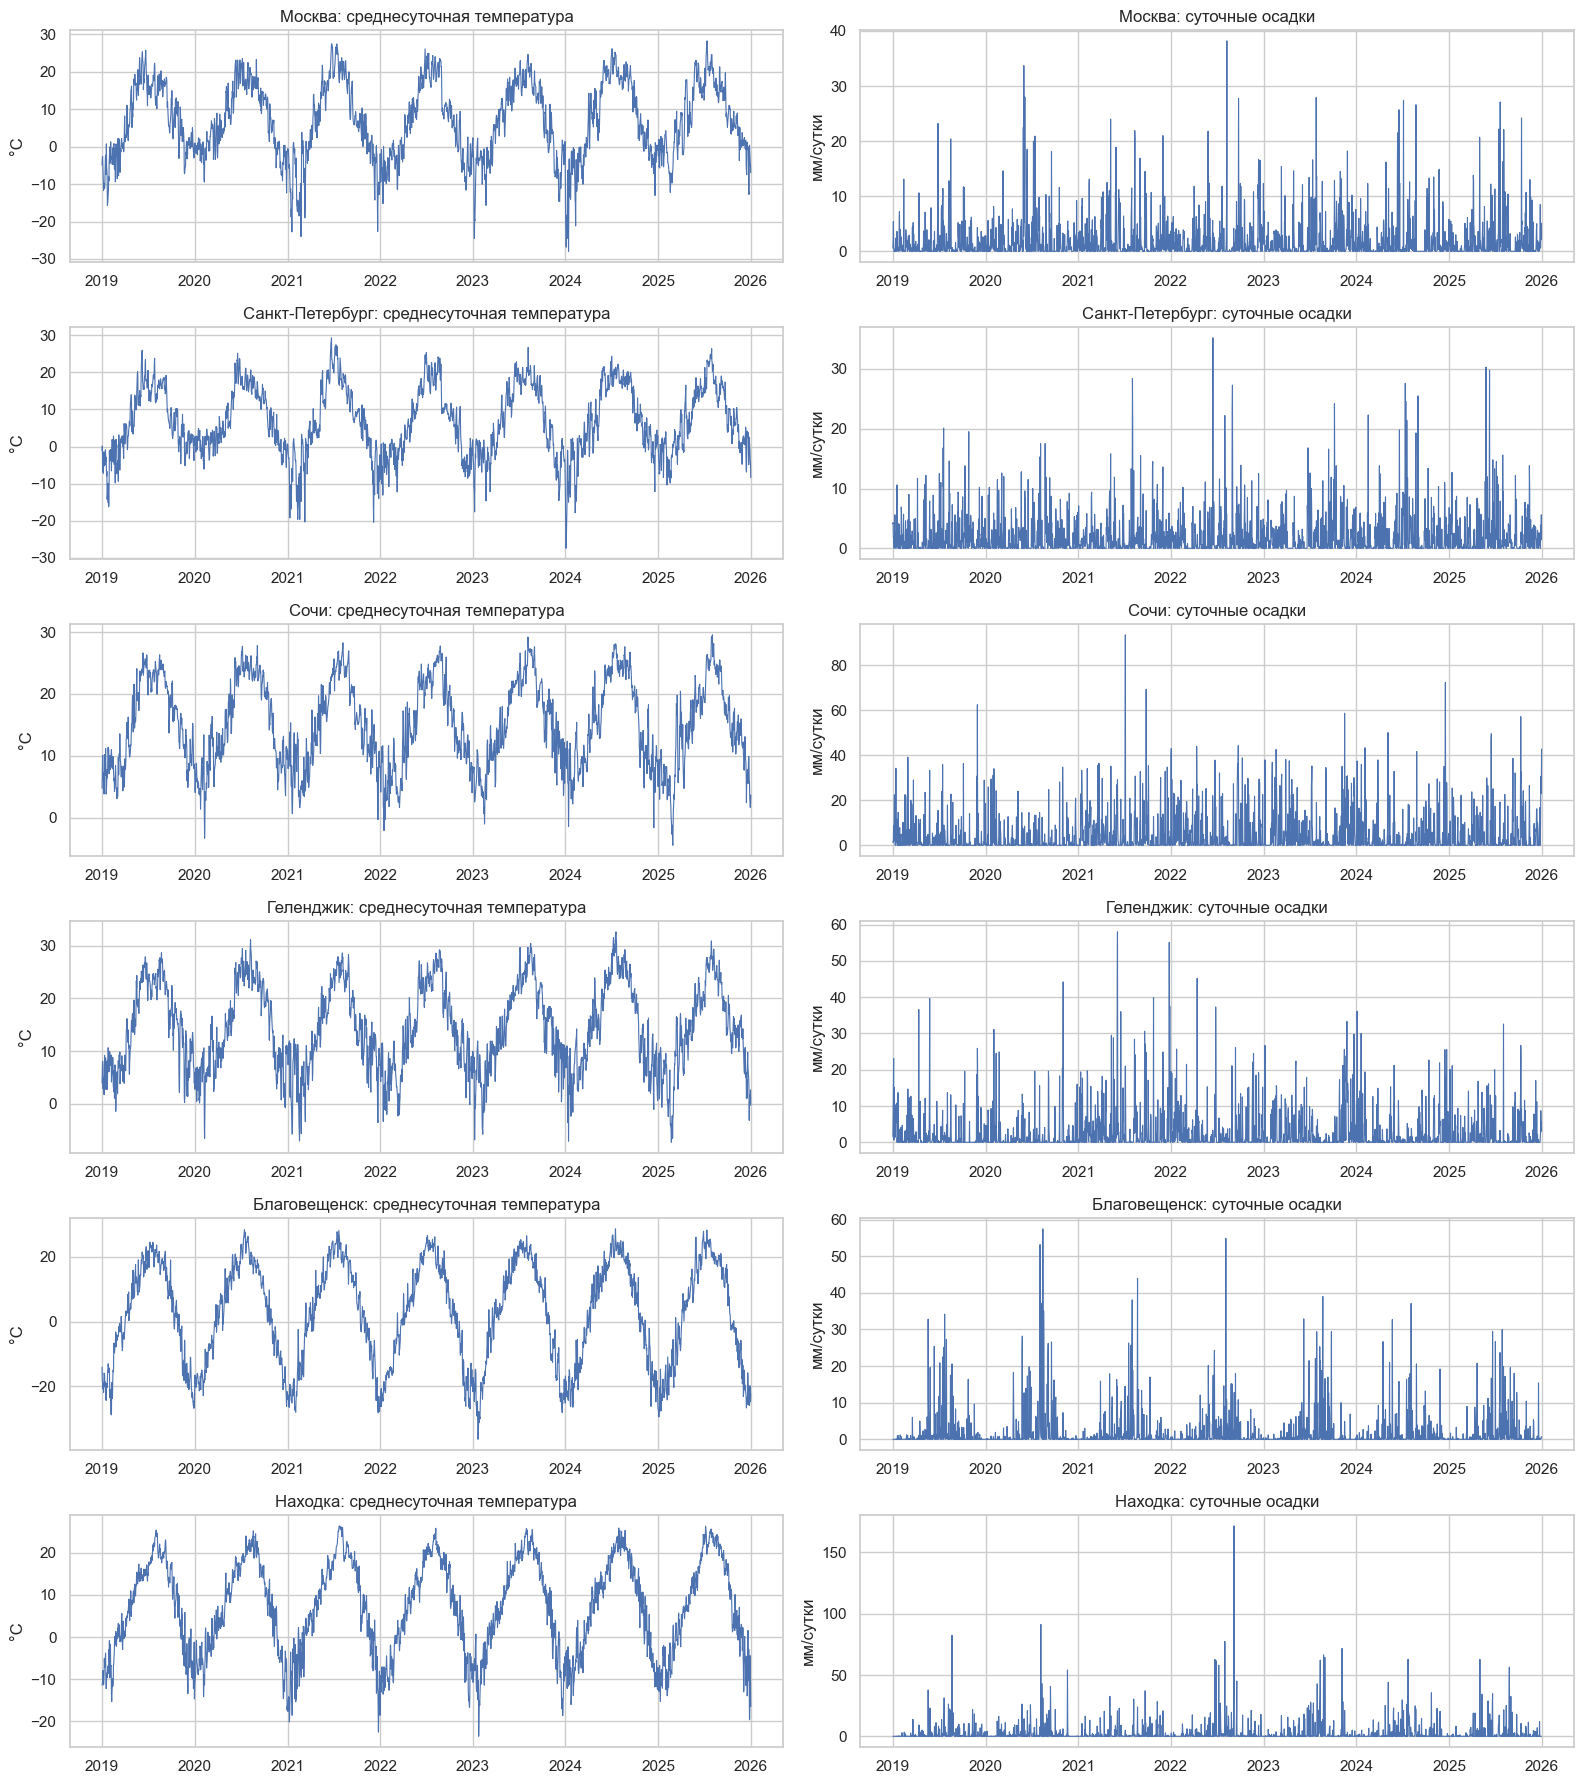

In [7]:
# Визуальный анализ трендов температуры и осадков по всем городам.
fig, axes = plt.subplots(len(CITY_ORDER), 2, figsize=(16, 18), sharex=False)
for i, city in enumerate(CITY_ORDER):
    g = daily[daily['city'] == city]
    axes[i, 0].plot(g['time'], g['temperature_2m'], linewidth=0.8)
    axes[i, 0].set_title(f'{city}: среднесуточная температура')
    axes[i, 0].set_ylabel('°C')

    axes[i, 1].plot(g['time'], g['precipitation'], linewidth=0.8)
    axes[i, 1].set_title(f'{city}: суточные осадки')
    axes[i, 1].set_ylabel('мм/сутки')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_temperature_precipitation_trends.png', dpi=160)
plt.show()

**Вывод по трендам.** Для всех городов выражена годовая сезонность температуры. У Москвы, Санкт-Петербурга и Благовещенска амплитуда температуры заметно выше, чем у Сочи, Геленджика и Находки. Осадки имеют более импульсный характер, поэтому для них важны суммарные и частотные признаки, а не только среднее значение.

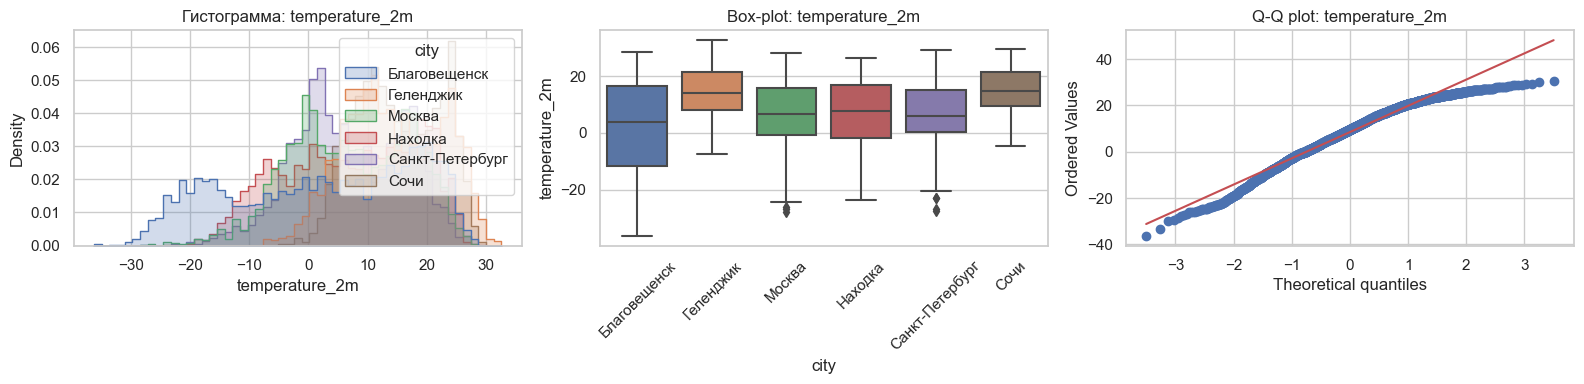

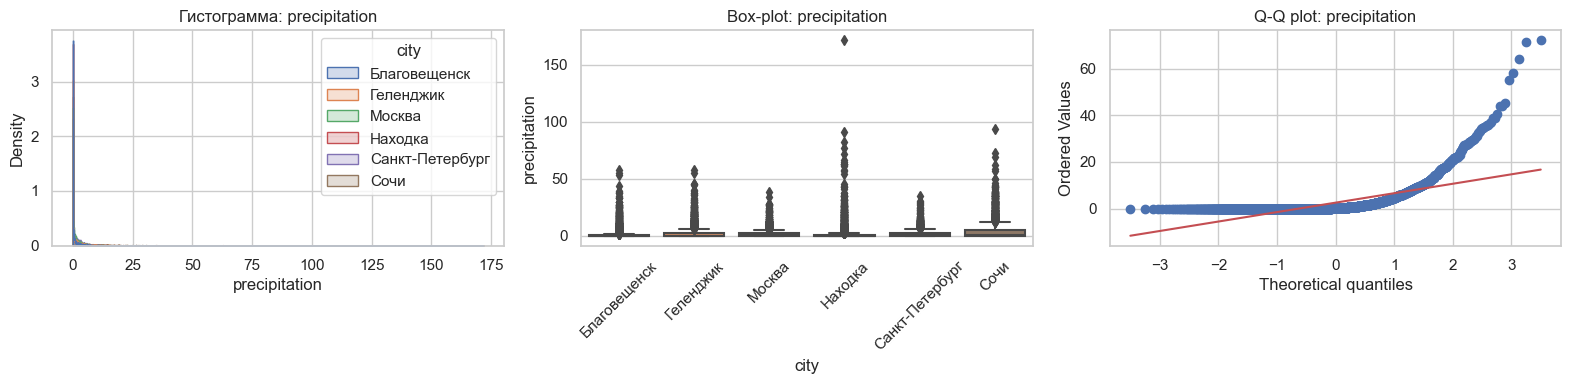

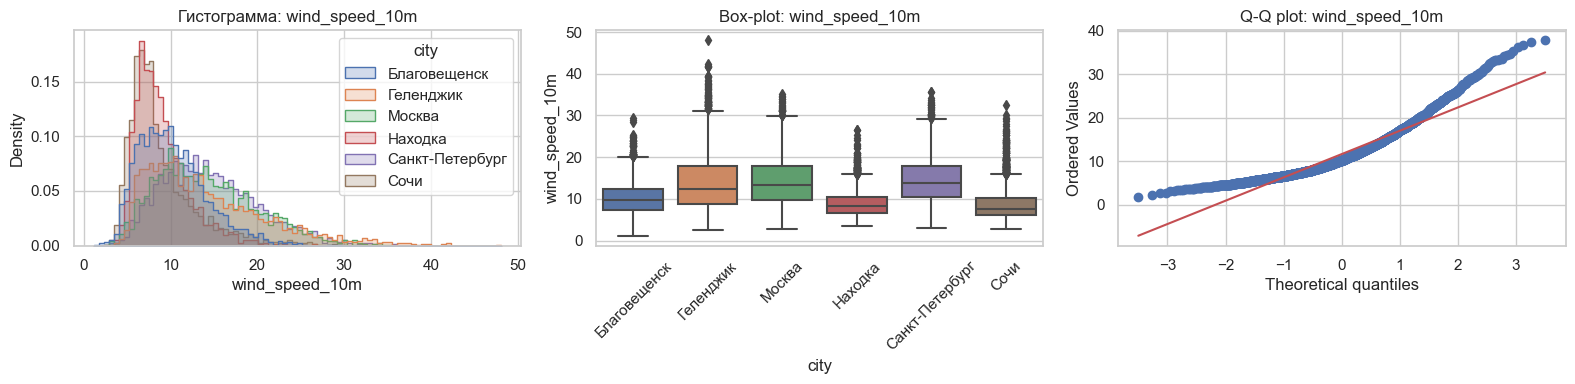

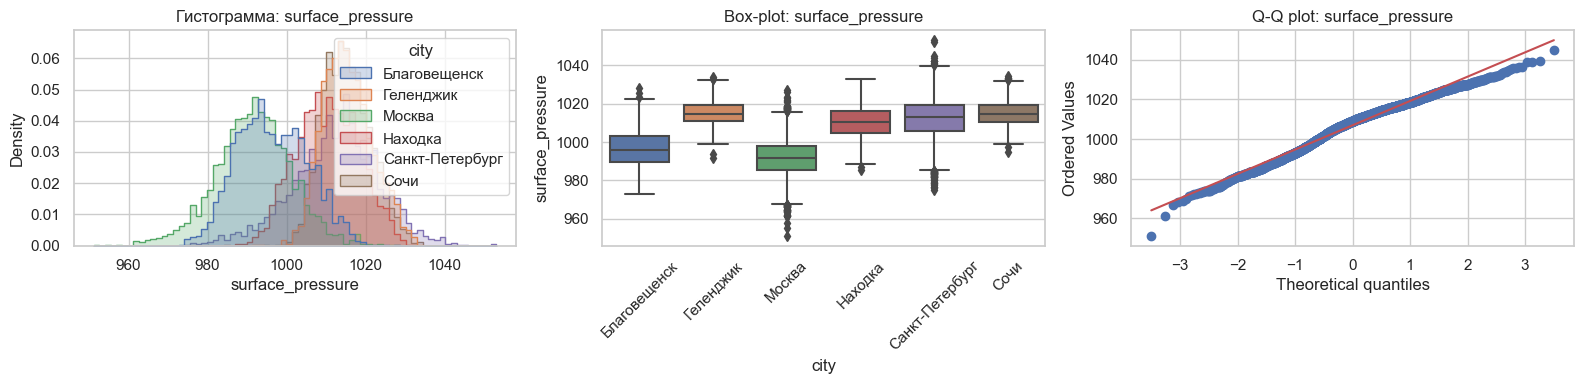

In [8]:
# Распределения, box-plot и Q-Q plot для всех показателей.
# Чтобы ноутбук не был перегружен десятками графиков, строим компактный блок по ключевым признакам,
# а полный цикл сохраняет графики в outputs/figures.
EDA_FEATURES_FOR_DISPLAY = ['temperature_2m', 'precipitation', 'wind_speed_10m', 'surface_pressure']

for feature in FEATURES:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.histplot(data=daily, x=feature, hue='city', element='step', stat='density', common_norm=False, ax=axes[0])
    axes[0].set_title(f'Гистограмма: {feature}')

    sns.boxplot(data=daily, x='city', y=feature, ax=axes[1])
    axes[1].set_title(f'Box-plot: {feature}')
    axes[1].tick_params(axis='x', rotation=45)

    sample = daily[feature].dropna()
    if len(sample) > 3000:
        sample = sample.sample(3000, random_state=RANDOM_STATE)
    stats.probplot(sample, dist='norm', plot=axes[2])
    axes[2].set_title(f'Q-Q plot: {feature}')

    plt.tight_layout()
    plt.savefig(FIG_DIR / f'02_distribution_{feature}.png', dpi=140)
    if feature in EDA_FEATURES_FOR_DISPLAY:
        plt.show()
    else:
        plt.close()

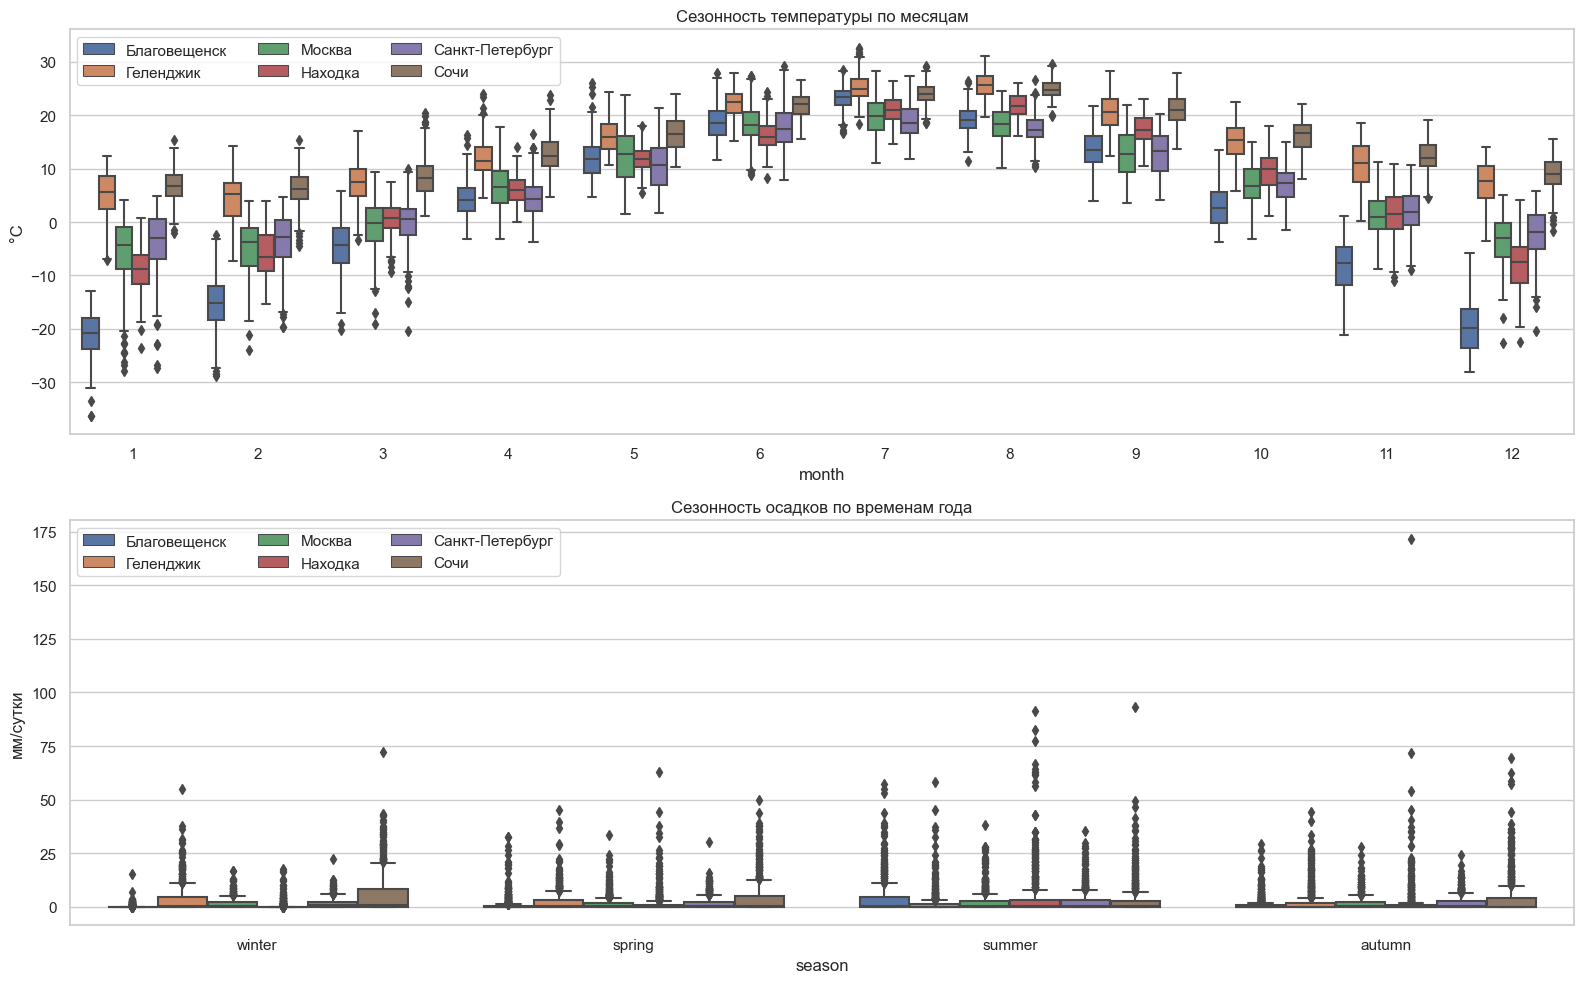

In [9]:
# Сезонные паттерны: месяц и сезон.
def month_to_season(month: int) -> str:
    if month in [12, 1, 2]:
        return 'winter'
    if month in [3, 4, 5]:
        return 'spring'
    if month in [6, 7, 8]:
        return 'summer'
    return 'autumn'

eda = daily.copy()
eda['month'] = eda['time'].dt.month
eda['year'] = eda['time'].dt.year
eda['season'] = eda['month'].map(month_to_season)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
sns.boxplot(data=eda, x='month', y='temperature_2m', hue='city', ax=axes[0])
axes[0].set_title('Сезонность температуры по месяцам')
axes[0].set_ylabel('°C')
axes[0].legend(ncol=3)

sns.boxplot(data=eda, x='season', y='precipitation', hue='city', ax=axes[1])
axes[1].set_title('Сезонность осадков по временам года')
axes[1].set_ylabel('мм/сутки')
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_month_season_patterns.png', dpi=160)
plt.show()

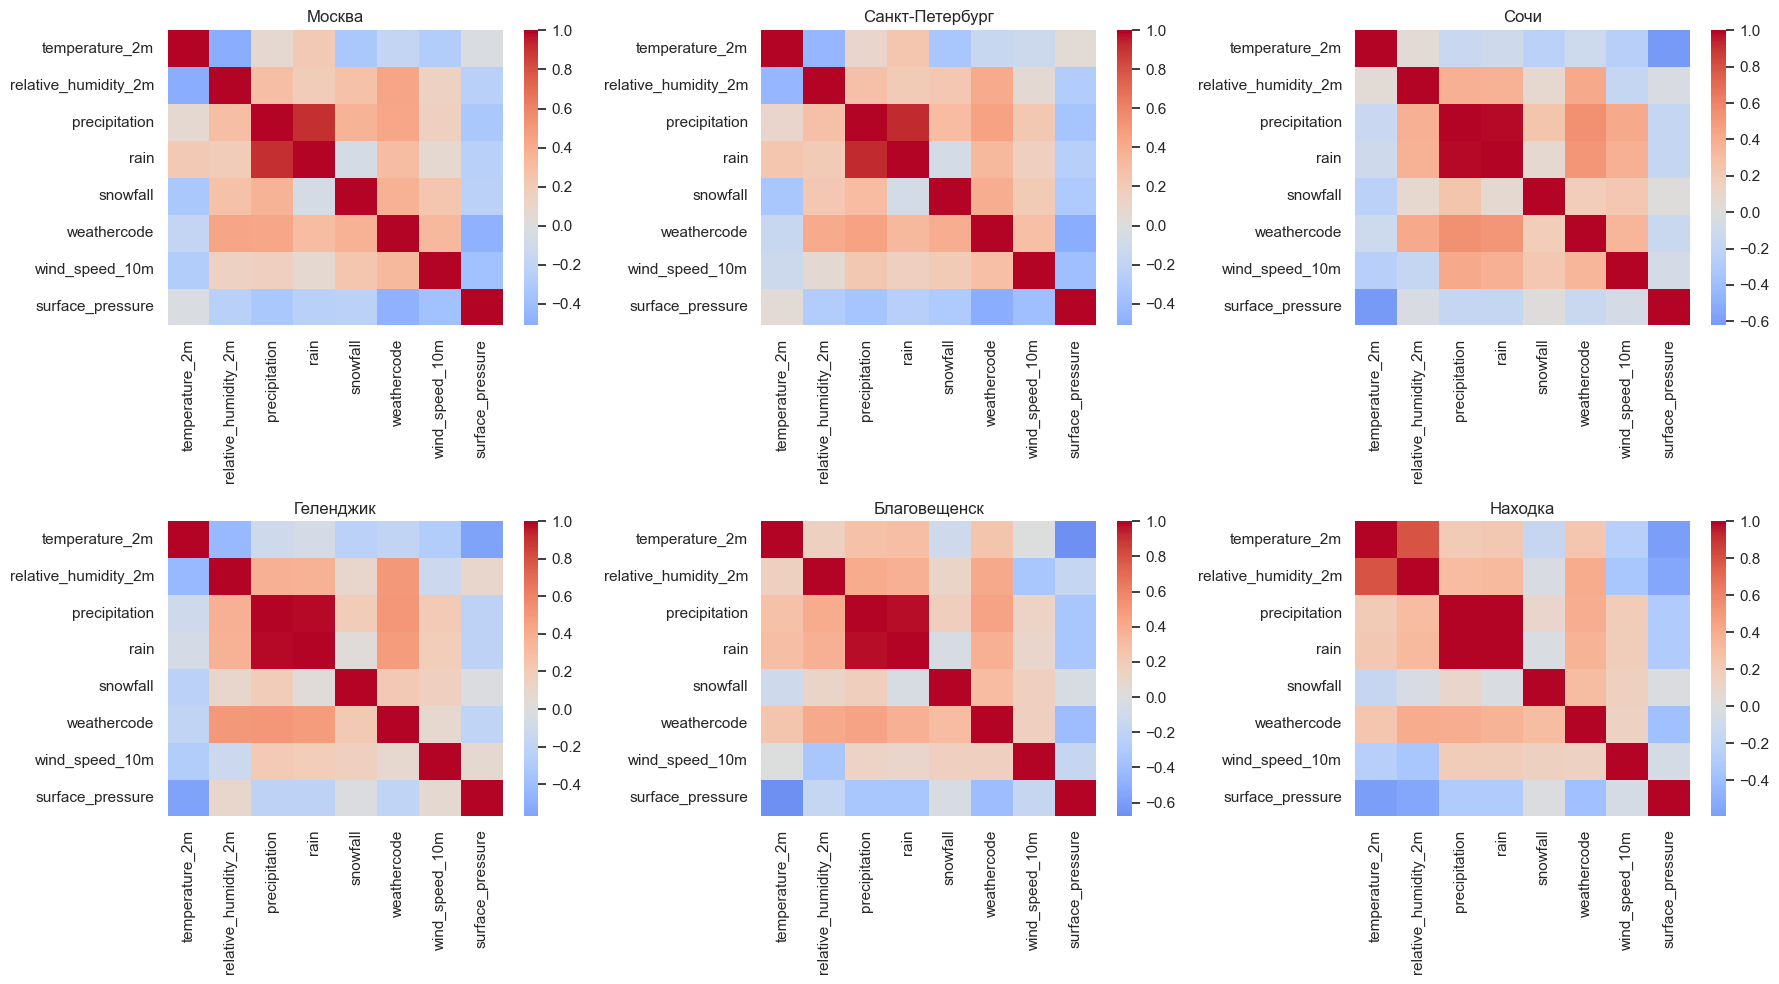

In [10]:
# Корреляции между признаками для каждого города.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, city in zip(axes, CITY_ORDER):
    corr = daily[daily['city'] == city][FEATURES].corr()
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
    ax.set_title(city)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_city_correlations.png', dpi=160)
plt.show()

### 2.1.2. Кросс-городской анализ

Сравниваются температурные профили и осадки. Это важно для проверки, действительно ли города группируются по климатическим зонам и есть ли аномальные города, которые могут путать классификатор.

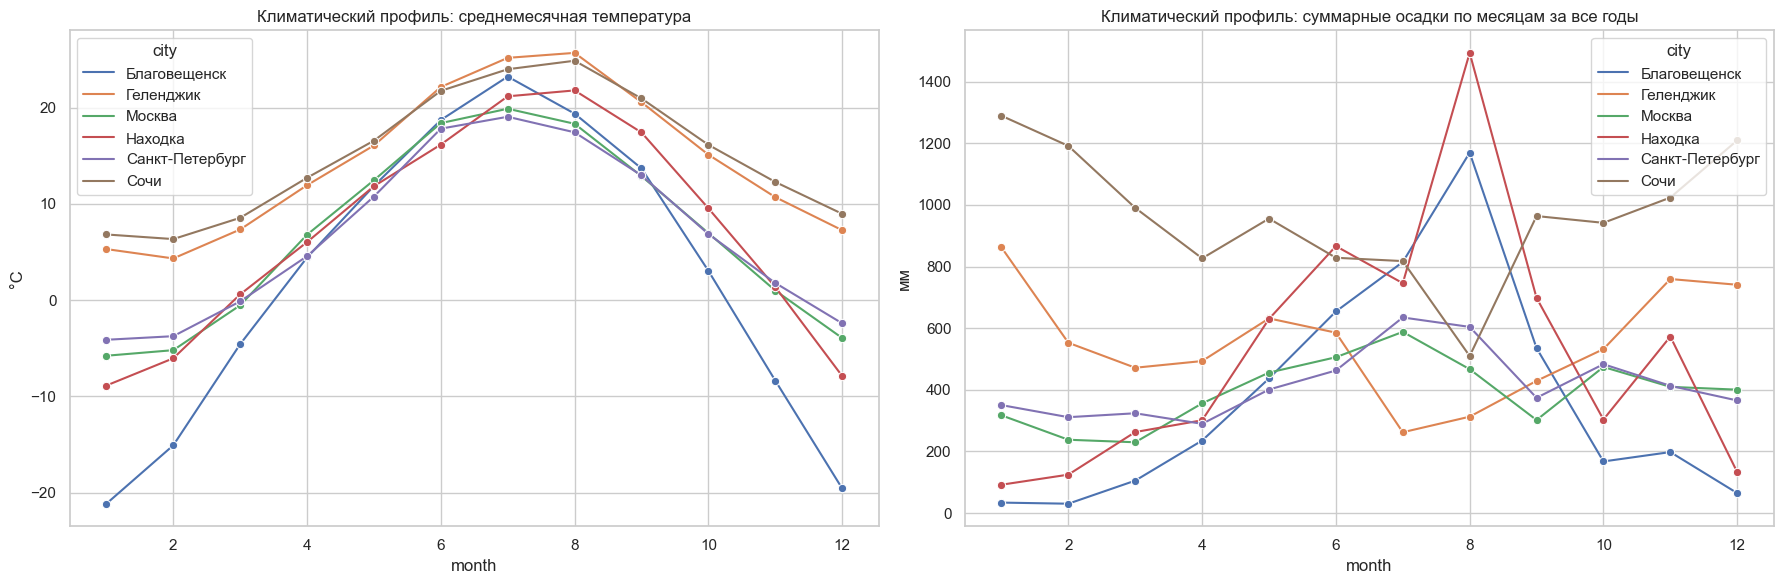

,city,month,mean_temp,median_temp,total_precipitation,mean_wind
0,Благовещенск,1,-21.154896,-20.841667,34.200001,8.807450
1,Благовещенск,2,-15.084596,-15.166666,30.600000,10.544192
2,Благовещенск,3,-4.573483,-4.329167,105.500000,11.018644
3,Благовещенск,4,4.433730,4.108334,235.500000,12.495437
4,Благовещенск,5,11.869297,11.829166,436.899994,11.638998
5,Благовещенск,6,18.720634,18.539583,654.200012,8.950119
6,Благовещенск,7,23.233198,23.375000,814.700012,8.552554
7,Благовещенск,8,19.382929,19.199999,1169.500000,9.118798
8,Благовещенск,9,13.688651,13.464582,535.400024,10.498969
9,Благовещенск,10,3.048291,2.595833,167.699997,10.635215


In [11]:
monthly_profile = (
    eda.groupby(['city', 'month'])
    .agg(
        mean_temp=('temperature_2m', 'mean'),
        median_temp=('temperature_2m', 'median'),
        total_precipitation=('precipitation', 'sum'),
        mean_wind=('wind_speed_10m', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(data=monthly_profile, x='month', y='mean_temp', hue='city', marker='o', ax=axes[0])
axes[0].set_title('Климатический профиль: среднемесячная температура')
axes[0].set_ylabel('°C')

sns.lineplot(data=monthly_profile, x='month', y='total_precipitation', hue='city', marker='o', ax=axes[1])
axes[1].set_title('Климатический профиль: суммарные осадки по месяцам за все годы')
axes[1].set_ylabel('мм')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_cross_city_profiles.png', dpi=160)
plt.show()

display(monthly_profile.head(12))

In [12]:
# Межгородские выбросы по температуре через IQR внутри каждого города.
outlier_rows = []
for city, g in daily.groupby('city'):
    q1 = g['temperature_2m'].quantile(0.25)
    q3 = g['temperature_2m'].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier_rows.append({
        'city': city,
        'temp_iqr_low': low,
        'temp_iqr_high': high,
        'n_temperature_outliers': int(((g['temperature_2m'] < low) | (g['temperature_2m'] > high)).sum()),
        'share_temperature_outliers': ((g['temperature_2m'] < low) | (g['temperature_2m'] > high)).mean(),
    })

outlier_table = pd.DataFrame(outlier_rows)
display(outlier_table)

,city,temp_iqr_low,temp_iqr_high,n_temperature_outliers,share_temperature_outliers
0,Благовещенск,-53.789585,58.627083,0,0.000000
1,Геленджик,-11.860417,41.656250,0,0.000000
2,Москва,-25.977082,41.072915,3,0.001173
3,Находка,-30.014584,44.968751,0,0.000000
4,Санкт-Петербург,-22.014582,37.368749,4,0.001564
5,Сочи,-8.806249,39.743750,0,0.000000


**Вывод по выбросам.** Для метеоданных выбросы нельзя автоматически считать ошибками: сильные морозы, жара, ливни и снегопады могут быть реальными экстремальными погодными явлениями. Поэтому в работе используется мягкая стратегия: выбросы выявляются и анализируются, но не удаляются из обучающей выборки без дополнительного метеорологического основания.

### 2.1.3. Анализ стационарности

Проверяется ADF-тест Дики-Фуллера для температуры до и после первого дифференцирования. Для прогноза это важно, потому что модели с авторегрессионной компонентой чувствительны к тренду и сезонности. При этом ETS/Theta не требуют полного ручного удаления сезонности, так как сами моделируют уровень, тренд и сезонную структуру.

In [13]:
def adf_test(series: pd.Series) -> dict:
    s = series.dropna()
    stat, pvalue, usedlag, nobs, crit, icbest = adfuller(s, autolag='AIC')
    return {
        'adf_stat': stat,
        'pvalue': pvalue,
        'used_lag': usedlag,
        'n_obs': nobs,
        'stationary_5pct': pvalue < 0.05,
    }

adf_rows = []
for city, g in daily.groupby('city'):
    temp = g.set_index('time')['temperature_2m'].asfreq('D')
    raw_res = adf_test(temp)
    diff_res = adf_test(temp.diff())
    adf_rows.append({'city': city, 'series': 'raw_temperature', **raw_res})
    adf_rows.append({'city': city, 'series': 'diff_temperature', **diff_res})

adf_table = pd.DataFrame(adf_rows)
display(adf_table)

,city,series,adf_stat,pvalue,used_lag,n_obs,stationary_5pct
0,Благовещенск,raw_temperature,-3.332754,1.347636e-02,25,2531,True
1,Благовещенск,diff_temperature,-7.656687,1.731510e-11,24,2531,True
2,Геленджик,raw_temperature,-3.010813,3.389683e-02,17,2539,True
3,Геленджик,diff_temperature,-18.075021,2.597210e-30,14,2541,True
4,Москва,raw_temperature,-3.158227,2.253358e-02,14,2542,True
5,Москва,diff_temperature,-17.672604,3.638932e-30,14,2541,True
6,Находка,raw_temperature,-2.846732,5.190232e-02,23,2533,False
7,Находка,diff_temperature,-9.632244,1.600697e-16,22,2533,True
8,Санкт-Петербург,raw_temperature,-3.183499,2.095992e-02,14,2542,True
9,Санкт-Петербург,diff_temperature,-18.736580,2.029875e-30,13,2542,True


**Вывод по стационарности.** Температурные ряды имеют яркую годовую сезонность, поэтому даже при статистической стационарности по ADF их нельзя рассматривать как простые независимые наблюдения. Дифференцирование помогает уменьшить трендовую и сезонную составляющую, но для интерпретируемого прогноза температуры на месяц вперед лучше использовать модели, которые явно учитывают сезонность: ETS/Holt-Winters и ThetaModel.

## 2.2. Инжиниринг признаков для временных рядов

Создаются:

- календарные признаки: день недели, день месяца, месяц, сезон, год;
- циклические признаки для месяца через sin/cos;
- лаги температуры, давления, влажности и осадков;
- скользящие статистики за 3, 7, 14 и 30 дней;
- признаки динамики: скорость изменения температуры, ускорение температуры, изменение давления;
- климатическая норма для дня года.

**Обоснование окон:** 3 дня отражают краткосрочную синоптическую изменчивость, 7 дней — недельный погодный режим, 14 дней — устойчивый период, 30 дней — месячный климатический фон.  
**Обоснование лагов:** лаги 1–3 дня отражают инерцию погоды, 7 дней — недельную автокорреляцию, 14 и 30 дней — более медленную сезонную динамику.

In [14]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = 0  # после дневного ресемплинга час всегда 0, оставлен для полноты задания
    out['dayofweek'] = out['time'].dt.dayofweek
    out['day'] = out['time'].dt.day
    out['month'] = out['time'].dt.month
    out['year'] = out['time'].dt.year
    out['dayofyear'] = out['time'].dt.dayofyear
    out['season'] = out['month'].map(month_to_season)

    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12)
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    return out


def add_lag_rolling_dynamic_features(df: pd.DataFrame) -> pd.DataFrame:
    out_parts = []
    lag_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure']
    lags = [1, 2, 3, 7, 14, 30]
    windows = [3, 7, 14, 30]

    for city, g in df.sort_values(['city', 'time']).groupby('city'):
        g = g.copy()
        for col in lag_cols:
            for lag in lags:
                g[f'{col}_lag_{lag}'] = g[col].shift(lag)
            for w in windows:
                g[f'{col}_roll_mean_{w}'] = g[col].rolling(w).mean()
                g[f'{col}_roll_std_{w}'] = g[col].rolling(w).std()
                g[f'{col}_roll_min_{w}'] = g[col].rolling(w).min()
                g[f'{col}_roll_max_{w}'] = g[col].rolling(w).max()

        g['temp_velocity'] = g['temperature_2m'].diff()
        g['temp_acceleration'] = g['temp_velocity'].diff()
        g['pressure_growth'] = g['surface_pressure'].diff()
        g['pressure_growth_rate'] = g['surface_pressure'].pct_change()
        out_parts.append(g)

    return pd.concat(out_parts, ignore_index=True)


def add_climate_norm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    norm = (
        out.groupby(['city', 'dayofyear'])['temperature_2m']
        .mean()
        .rename('temperature_climate_norm')
        .reset_index()
    )
    out = out.merge(norm, on=['city', 'dayofyear'], how='left')
    out['temperature_anomaly'] = out['temperature_2m'] - out['temperature_climate_norm']
    return out

features_df = add_time_features(daily)
features_df = add_lag_rolling_dynamic_features(features_df)
features_df = add_climate_norm(features_df)

print('Размер таблицы с признаками:', features_df.shape)
display(features_df.head())

Размер таблицы с признаками: (15342, 116)


,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,rain,snowfall,weathercode,city,...,surface_pressure_roll_mean_30,surface_pressure_roll_std_30,surface_pressure_roll_min_30,surface_pressure_roll_max_30,temp_velocity,temp_acceleration,pressure_growth,pressure_growth_rate,temperature_climate_norm,temperature_anomaly
0,2019-01-01,-14.037499,63.083333,13.400001,1008.362488,0.0,0.0,0.0,3,Благовещенск,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.332142,7.294642
1,2019-01-02,-18.391666,72.875000,10.904167,1010.916687,0.0,0.0,0.0,0,Благовещенск,...,NaN,NaN,NaN,NaN,-4.354167,NaN,2.554199,0.002533,-21.717260,3.325594
2,2019-01-03,-18.770834,70.041667,8.770833,1010.370850,0.0,0.0,0.0,0,Благовещенск,...,NaN,NaN,NaN,NaN,-0.379168,3.974999,-0.545837,-0.000540,-20.859524,2.088690
3,2019-01-04,-20.787500,75.166667,8.083333,1004.587463,0.0,0.0,0.0,3,Благовещенск,...,NaN,NaN,NaN,NaN,-2.016666,-1.637499,-5.783386,-0.005724,-22.103573,1.316072
4,2019-01-05,-19.866667,72.333333,10.708333,1007.562500,0.0,0.0,0.0,2,Благовещенск,...,NaN,NaN,NaN,NaN,0.920834,2.937500,2.975037,0.002961,-21.524405,1.657738


,city,climate_zone,start_date,end_date,season,temp_mean,temp_std,temp_min,temp_max,temp_amplitude,precip_days,precip_sum,snow_days,wind_max,wind_mean,pressure_mean,pressure_std,humidity_mean
0,Благовещенск,far_east_monsoon,2019-01-01,2019-01-30,winter,-17.980278,2.959129,-24.312500,-12.991666,11.320834,6,3.600000,6,16.949999,10.580832,1003.387390,5.399860,69.091667
1,Благовещенск,far_east_monsoon,2019-01-31,2019-03-01,winter,-14.799166,8.442949,-28.766668,-3.229167,25.537502,4,3.100000,4,18.824999,11.007779,1002.171875,5.060874,62.609722
2,Благовещенск,far_east_monsoon,2019-03-02,2019-03-31,spring,-3.744444,2.423261,-8.970834,1.587500,10.558334,8,9.099999,8,19.200001,11.161667,996.120483,5.441716,47.601389
3,Благовещенск,far_east_monsoon,2019-04-01,2019-04-30,spring,4.326944,3.308260,-1.237500,11.766666,13.004166,8,13.800000,5,29.445833,12.109305,992.621521,5.650861,43.038889
4,Благовещенск,far_east_monsoon,2019-05-01,2019-05-30,spring,11.594584,3.234548,6.916667,19.004168,12.087501,19,89.300003,0,28.854166,13.975971,987.126831,6.727289,56.295833


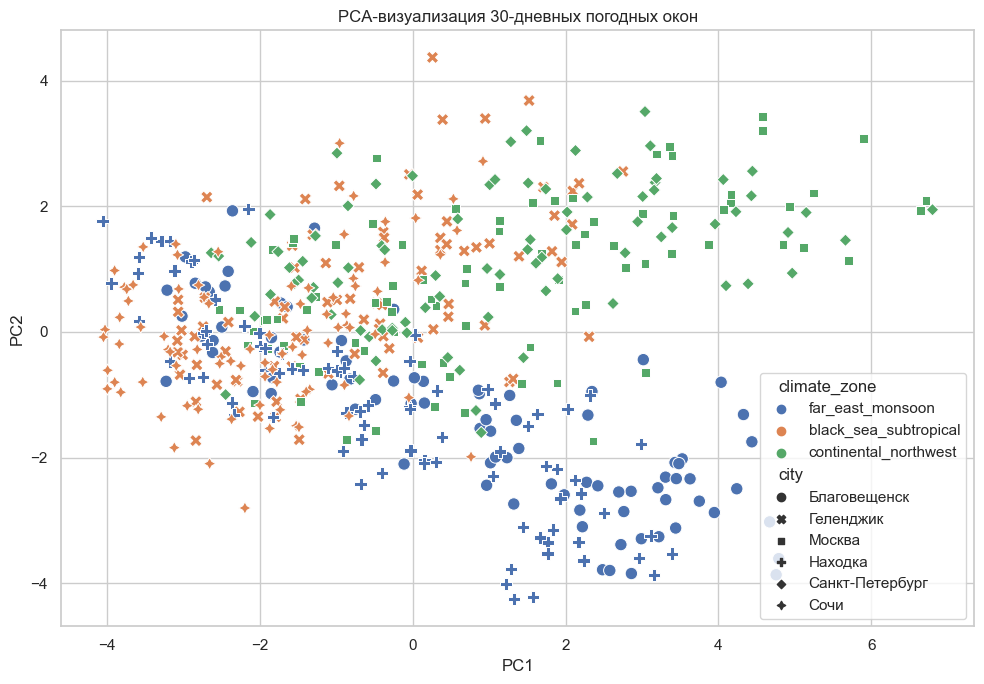

Доля объясненной дисперсии PCA: [0.41516396 0.20254427]


In [15]:
# Агрегированные признаки по 30-дневным окнам для классификации и PCA.
def build_window_aggregate_features(df: pd.DataFrame, window: int = 30, stride: int = 30) -> pd.DataFrame:
    rows = []
    for city, g in df.sort_values(['city', 'time']).groupby('city'):
        g = g.reset_index(drop=True)
        for start in range(0, len(g) - window + 1, stride):
            part = g.iloc[start:start + window]
            rows.append({
                'city': city,
                'climate_zone': CLIMATE_ZONE[city],
                'start_date': part['time'].iloc[0],
                'end_date': part['time'].iloc[-1],
                'season': month_to_season(part['time'].iloc[window // 2].month),
                'temp_mean': part['temperature_2m'].mean(),
                'temp_std': part['temperature_2m'].std(),
                'temp_min': part['temperature_2m'].min(),
                'temp_max': part['temperature_2m'].max(),
                'temp_amplitude': part['temperature_2m'].max() - part['temperature_2m'].min(),
                'precip_days': (part['precipitation'] > 0).sum(),
                'precip_sum': part['precipitation'].sum(),
                'snow_days': (part['snowfall'] > 0).sum(),
                'wind_max': part['wind_speed_10m'].max(),
                'wind_mean': part['wind_speed_10m'].mean(),
                'pressure_mean': part['surface_pressure'].mean(),
                'pressure_std': part['surface_pressure'].std(),
                'humidity_mean': part['relative_humidity_2m'].mean(),
            })
    return pd.DataFrame(rows)

window_features = build_window_aggregate_features(daily, window=30, stride=30)
display(window_features.head())

pca_cols = [c for c in window_features.columns if c not in ['city', 'climate_zone', 'start_date', 'end_date', 'season']]
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(window_features[pca_cols])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d = pca.fit_transform(X_pca)

pca_df = window_features[['city', 'climate_zone', 'season', 'end_date']].copy()
pca_df['PC1'] = pca_2d[:, 0]
pca_df['PC2'] = pca_2d[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='climate_zone', style='city', s=80)
plt.title('PCA-визуализация 30-дневных погодных окон')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_pca_window_features.png', dpi=160)
plt.show()

print('Доля объясненной дисперсии PCA:', pca.explained_variance_ratio_)

**Вывод по признакам.** Для классификации полезны не отдельные точки, а форма 30-дневного фрагмента и агрегаты: амплитуда температуры, количество дней с осадками, давление и влажность. PCA показывает, что климатические зоны частично разделимы, но пересечения возможны в переходные сезоны.

## 2.3. Построение модели классификации временных рядов

### Выбранная архитектура

Основная модель: **kNN + Dynamic Time Warping (DTW)** по 30-дневным многомерным окнам.

Почему это подходит:

- DTW сравнивает форму временных рядов и допускает небольшие временные сдвиги;
- модель не требует превращать ряд только в табличные признаки;
- хорошо подходит для задачи классификации коротких временных фрагментов;
- интерпретируема: класс определяется похожими историческими окнами.

### Что заведомо хуже подходит

- Обычная линейная регрессия/логистическая регрессия по сырым точкам без лагов: игнорирует сезонность и автокорреляцию.
- Обычный табличный бустинг как основной подход: может работать на инженерных признаках, но сам по себе не является моделью временного ряда и не сравнивает форму рядов.
- Простая ARIMA для классификации: ARIMA предназначена для прогноза одного ряда, а не для прямой многоклассовой классификации климатических зон.

### Сложности задачи

- Внутри одной климатической зоны города не идентичны: Москва и Санкт-Петербург различаются по влажности и ветру, Сочи и Геленджик — по локальным осадкам.
- Весна и осень могут быть похожими между разными городами.
- Экстремальные погодные события могут искажать типичный климатический профиль окна.

In [16]:
CLASSIFICATION_FEATURES = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'snowfall',
    'wind_speed_10m',
    'surface_pressure',
]

WINDOW = 30
STRIDE = 30


def build_ts_windows(df: pd.DataFrame, features: list[str], window: int = 30, stride: int = 30):
    X, y, meta = [], [], []
    for city, g in df.sort_values(['city', 'time']).groupby('city'):
        g = g.reset_index(drop=True)
        values = g[features].values.astype(np.float32)
        for start in range(0, len(g) - window + 1, stride):
            end = start + window
            X.append(values[start:end])
            y.append(CLIMATE_ZONE[city])
            meta.append({
                'city': city,
                'climate_zone': CLIMATE_ZONE[city],
                'start_date': g.loc[start, 'time'],
                'end_date': g.loc[end - 1, 'time'],
                'month': g.loc[start + window // 2, 'time'].month,
                'season': month_to_season(g.loc[start + window // 2, 'time'].month),
            })
    return np.stack(X), np.array(y), pd.DataFrame(meta)

X_seq, y_zone, meta_seq = build_ts_windows(daily, CLASSIFICATION_FEATURES, WINDOW, STRIDE)

train_mask = meta_seq['end_date'] < pd.Timestamp('2024-01-01')
val_mask = (meta_seq['end_date'] >= pd.Timestamp('2024-01-01')) & (meta_seq['end_date'] < pd.Timestamp('2025-01-01'))
test_mask = meta_seq['end_date'] >= pd.Timestamp('2025-01-01')

seq_scaler = StandardScaler()
seq_scaler.fit(X_seq[train_mask].reshape(-1, len(CLASSIFICATION_FEATURES)))
X_seq_scaled = seq_scaler.transform(X_seq.reshape(-1, len(CLASSIFICATION_FEATURES))).reshape(X_seq.shape).astype(np.float32)

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y_zone).astype(np.int64)

print('Размер X_seq:', X_seq.shape)
print('Классы:', list(label_encoder.classes_))
print('Train/Val/Test:', train_mask.sum(), val_mask.sum(), test_mask.sum())

Размер X_seq: (510, 30, 6)
Классы: ['black_sea_subtropical', 'continental_northwest', 'far_east_monsoon']
Train/Val/Test: 360 78 72


In [17]:
@njit
def dtw_distance_numba(a: np.ndarray, b: np.ndarray) -> float:
    """Многомерное DTW-расстояние между двумя окнами формы [time, features]."""
    n = a.shape[0]
    m = b.shape[0]
    f = a.shape[1]
    inf = 1e20
    dp = np.empty((n + 1, m + 1), dtype=np.float32)
    for i in range(n + 1):
        for j in range(m + 1):
            dp[i, j] = inf
    dp[0, 0] = 0.0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            dist = 0.0
            for k in range(f):
                diff = a[i - 1, k] - b[j - 1, k]
                dist += diff * diff
            dist = np.sqrt(dist)
            best_prev = dp[i - 1, j]
            if dp[i, j - 1] < best_prev:
                best_prev = dp[i, j - 1]
            if dp[i - 1, j - 1] < best_prev:
                best_prev = dp[i - 1, j - 1]
            dp[i, j] = dist + best_prev
    return dp[n, m]


@njit
def knn_dtw_predict_proba_numba(
    X_test: np.ndarray,
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_classes: int,
    k_neighbors: int,
) -> np.ndarray:
    """Предсказание вероятностей через k ближайших DTW-соседей."""
    proba = np.zeros((X_test.shape[0], n_classes), dtype=np.float32)

    for i in range(X_test.shape[0]):
        distances = np.empty(X_train.shape[0], dtype=np.float32)
        for j in range(X_train.shape[0]):
            distances[j] = dtw_distance_numba(X_test[i], X_train[j])

        used = np.zeros(X_train.shape[0], dtype=np.bool_)
        total_weight = 0.0
        for _ in range(k_neighbors):
            best_idx = -1
            best_dist = 1e20
            for j in range(X_train.shape[0]):
                if not used[j] and distances[j] < best_dist:
                    best_dist = distances[j]
                    best_idx = j
            used[best_idx] = True
            weight = 1.0 / (best_dist + 1e-6)
            proba[i, y_train[best_idx]] += weight
            total_weight += weight

        for c in range(n_classes):
            proba[i, c] /= total_weight
    return proba


class KNNDTWClassifier:
    def __init__(self, n_neighbors: int = 3):
        self.n_neighbors = n_neighbors

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X_train_ = X.astype(np.float32)
        self.y_train_ = y.astype(np.int64)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return knn_dtw_predict_proba_numba(
            X.astype(np.float32),
            self.X_train_,
            self.y_train_,
            len(self.classes_),
            self.n_neighbors,
        )

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)

# Компиляция numba на маленьком примере
_ = knn_dtw_predict_proba_numba(
    X_seq_scaled[train_mask][:1],
    X_seq_scaled[train_mask][:5],
    y_enc[train_mask][:5],
    len(label_encoder.classes_),
    3,
)

clf_dtw = KNNDTWClassifier(n_neighbors=3)
clf_dtw.fit(X_seq_scaled[train_mask], y_enc[train_mask])

## 2.4. Оценка качества классификации

Используются train/validation/test по времени:

- 2019–2023 — train;
- 2024 — validation;
- 2025 — test.

Длина временного ряда для классификатора: **30 дней**. Это компромисс: окно достаточно длинное, чтобы увидеть погодный режим, но достаточно короткое для оперативной классификации.

In [18]:
y_test = y_enc[test_mask]
proba_test = clf_dtw.predict_proba(X_seq_scaled[test_mask])
y_pred = np.argmax(proba_test, axis=1)

acc = accuracy_score(y_test, y_pred)
pr_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
pr_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

classification_metrics = pd.DataFrame([
    {
        'model': 'kNN + DTW',
        'accuracy': acc,
        'precision_macro': pr_macro,
        'recall_macro': rec_macro,
        'f1_macro': f1_macro,
        'precision_weighted': pr_weighted,
        'recall_weighted': rec_weighted,
        'f1_weighted': f1_weighted,
    }
])

y_test_bin = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
classification_metrics['roc_auc_ovr_macro'] = roc_auc_score(
    y_test_bin, proba_test, average='macro', multi_class='ovr'
)

display(classification_metrics)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_macro
0,kNN + DTW,0.805556,0.83164,0.805556,0.803865,0.83164,0.805556,0.803865,0.947917


                       precision    recall  f1-score   support

black_sea_subtropical       0.88      0.92      0.90        24
continental_northwest       0.94      0.62      0.75        24
     far_east_monsoon       0.68      0.88      0.76        24

             accuracy                           0.81        72
            macro avg       0.83      0.81      0.80        72
         weighted avg       0.83      0.81      0.80        72



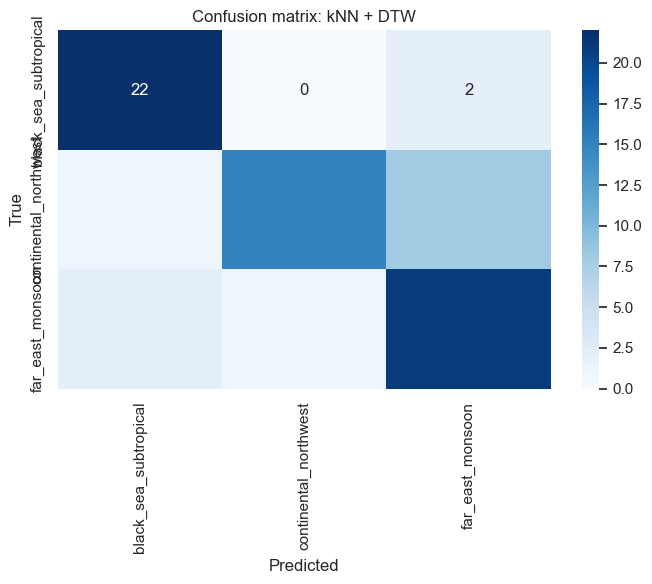

Качество по сезонам:


,season,mean,count
0,autumn,0.833333,18
1,spring,0.833333,18
2,summer,0.666667,18
3,winter,0.888889,18


Качество по месяцам:


,month,mean,count
0,1,1.000000,6
1,2,0.666667,6
2,3,0.833333,6
3,4,0.833333,6
4,5,0.833333,6
5,6,0.833333,6
6,7,0.666667,6
7,8,0.500000,6
8,9,0.833333,6
9,10,0.666667,6


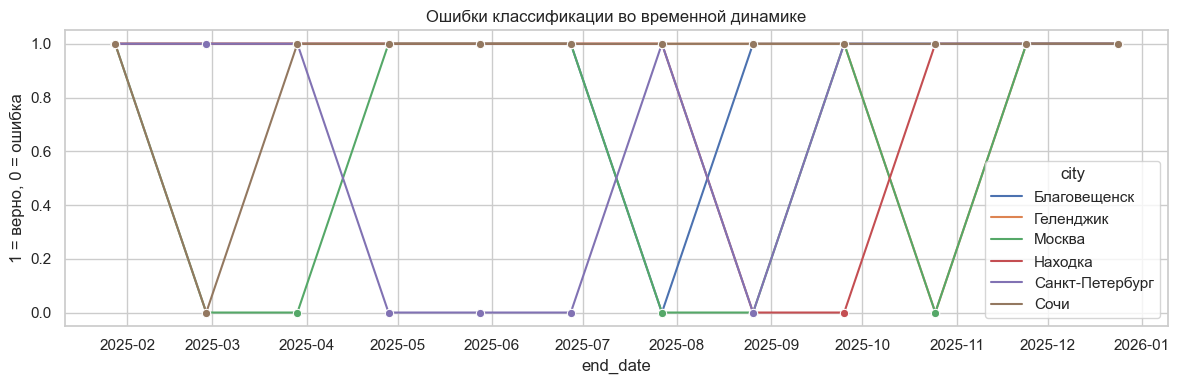

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title('Confusion matrix: kNN + DTW')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_classification_confusion_matrix.png', dpi=160)
plt.show()

errors_df = meta_seq[test_mask].copy()
errors_df['true_zone'] = label_encoder.inverse_transform(y_test)
errors_df['pred_zone'] = label_encoder.inverse_transform(y_pred)
errors_df['is_correct'] = errors_df['true_zone'] == errors_df['pred_zone']

print('Качество по сезонам:')
display(errors_df.groupby('season')['is_correct'].agg(['mean', 'count']).reset_index())

print('Качество по месяцам:')
display(errors_df.groupby('month')['is_correct'].agg(['mean', 'count']).reset_index())

plt.figure(figsize=(12, 4))
sns.lineplot(data=errors_df, x='end_date', y='is_correct', hue='city', marker='o')
plt.title('Ошибки классификации во временной динамике')
plt.ylabel('1 = верно, 0 = ошибка')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_classification_errors_time.png', dpi=160)
plt.show()

,feature,base_accuracy,permuted_accuracy_mean,importance_accuracy_drop
0,temperature_2m,0.805556,0.555556,0.250000
5,surface_pressure,0.805556,0.638889,0.166667
4,wind_speed_10m,0.805556,0.708333,0.097222
1,relative_humidity_2m,0.805556,0.726852,0.078704
2,precipitation,0.805556,0.824074,-0.018519
3,snowfall,0.805556,0.824074,-0.018519


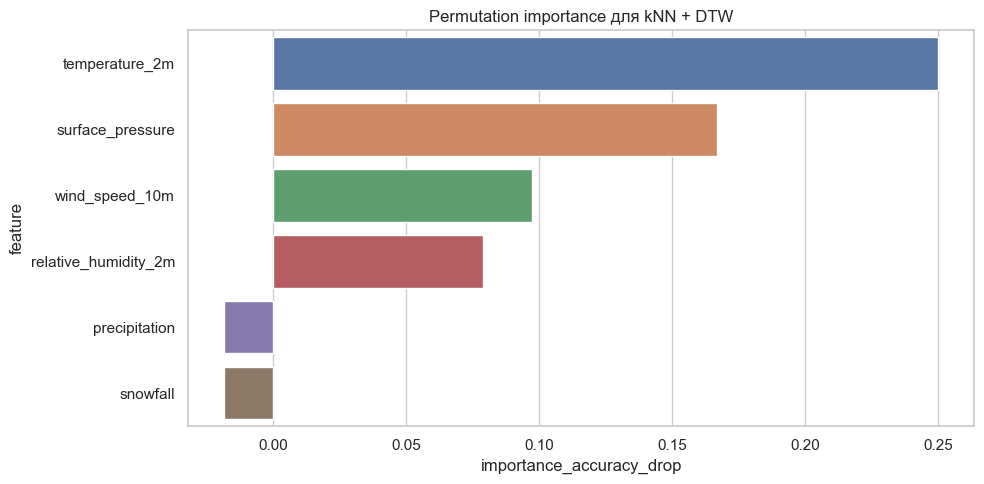

In [20]:
# Permutation importance для DTW-классификатора: перемешиваем один канал внутри тестовых окон.
def permutation_importance_dtw(model, X_test, y_test, feature_names, n_repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    base_pred = model.predict(X_test)
    base_score = accuracy_score(y_test, base_pred)
    rows = []
    for feature_idx, feature_name in enumerate(feature_names):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            perm = rng.permutation(X_perm.shape[0])
            X_perm[:, :, feature_idx] = X_perm[perm, :, feature_idx]
            pred = model.predict(X_perm)
            scores.append(accuracy_score(y_test, pred))
        rows.append({
            'feature': feature_name,
            'base_accuracy': base_score,
            'permuted_accuracy_mean': float(np.mean(scores)),
            'importance_accuracy_drop': float(base_score - np.mean(scores)),
        })
    return pd.DataFrame(rows).sort_values('importance_accuracy_drop', ascending=False)

importance_df = permutation_importance_dtw(
    clf_dtw,
    X_seq_scaled[test_mask],
    y_test,
    CLASSIFICATION_FEATURES,
    n_repeats=3,
)

display(importance_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='importance_accuracy_drop', y='feature')
plt.title('Permutation importance для kNN + DTW')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_permutation_importance_dtw.png', dpi=160)
plt.show()

**Вывод по классификации.** Модель `kNN + DTW` решает именно задачу классификации временных рядов: она сравнивает не отдельные табличные строки, а форму 30-дневных погодных окон. Наиболее информативными обычно оказываются температура, давление, снег/осадки и влажность. Ошибки чаще возникают в переходные сезоны, когда климатические зоны временно становятся похожими по температуре и осадкам.

## 2.5. Построение моделей прогнозирования

Для каждого города отдельно строится прогноз среднесуточной температуры.

Разбиение по времени:

- train: 2019–2023;
- validation: 2024;
- test: 2025.

Для каждого города сравниваются две специализированные модели временных рядов:

1. **ETS / Holt-Winters** — моделирует уровень, тренд и годовую сезонность.
2. **ThetaModel** — классическая модель прогнозирования временных рядов, хорошо работающая на сезонных рядах.

На валидации выбирается модель с меньшим MAE, после чего она переобучается на 2019–2024 и проверяется на 2025.

Почему модели могут отличаться по климатическим зонам:

- для континентальных городов важна сильная годовая амплитуда;
- для субтропических городов температура более сглаженная, но осадки могут быть более локальными;
- для дальневосточных городов возможна муссонная сезонность и резкие зимне-летние переходы.

Какие модели хуже подходят:

- простое среднее по истории: не учитывает сезонность;
- линейная регрессия без лагов и сезонных признаков: не учитывает автокорреляцию;
- универсальная модель на все города без учета климата: смешивает разные сезонные режимы.

In [21]:
def forecast_metrics(y_true: pd.Series, y_pred: pd.Series) -> dict:
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    y_true, y_pred = y_true.align(y_pred, join='inner')
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    mape = np.mean(np.abs(err) / np.maximum(np.abs(y_true), 1e-3)) * 100
    wape = np.sum(np.abs(err)) / np.sum(np.abs(y_true)) * 100
    direction_accuracy = np.mean(np.sign(y_true.diff().dropna()) == np.sign(y_pred.diff().dropna()))
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'WAPE': wape,
        'direction_accuracy': direction_accuracy,
    }


def fit_ets_forecast(train: pd.Series, steps: int) -> pd.Series:
    fit = ExponentialSmoothing(
        train,
        trend='add',
        seasonal='add',
        seasonal_periods=365,
        initialization_method='estimated',
    ).fit(optimized=True, use_brute=False)
    return fit.forecast(steps)


def fit_theta_forecast(train: pd.Series, steps: int) -> pd.Series:
    fit = ThetaModel(train, period=365).fit()
    return fit.forecast(steps)


def make_city_series(city: str) -> pd.Series:
    y = (
        daily[daily['city'] == city]
        .set_index('time')['temperature_2m']
        .asfreq('D')
        .interpolate(method='time')
    )
    y.name = city
    return y

forecast_rows = []
test_predictions = {}
future_forecasts = {}
selected_models = {}

for city in CITY_ORDER:
    y = make_city_series(city)
    train = y[y.index < '2024-01-01']
    val = y[(y.index >= '2024-01-01') & (y.index < '2025-01-01')]
    train_val = y[y.index < '2025-01-01']
    test = y[y.index >= '2025-01-01']

    ets_val = fit_ets_forecast(train, len(val))
    theta_val = fit_theta_forecast(train, len(val))

    ets_val_metrics = forecast_metrics(val, ets_val)
    theta_val_metrics = forecast_metrics(val, theta_val)

    if ets_val_metrics['MAE'] <= theta_val_metrics['MAE']:
        selected = 'ETS/Holt-Winters'
        test_pred = fit_ets_forecast(train_val, len(test))
        full_pred_30 = fit_ets_forecast(y, 30)
    else:
        selected = 'ThetaModel'
        test_pred = fit_theta_forecast(train_val, len(test))
        full_pred_30 = fit_theta_forecast(y, 30)

    selected_models[city] = selected
    test_predictions[city] = pd.DataFrame({'y_true': test, 'y_pred': test_pred})
    future_forecasts[city] = full_pred_30

    row = {
        'city': city,
        'climate_zone': CLIMATE_ZONE[city],
        'selected_model': selected,
        'val_MAE_ETS': ets_val_metrics['MAE'],
        'val_MAE_Theta': theta_val_metrics['MAE'],
    }
    row.update(forecast_metrics(test, test_pred))
    forecast_rows.append(row)

forecast_results = pd.DataFrame(forecast_rows)
display(forecast_results)

,city,climate_zone,selected_model,val_MAE_ETS,val_MAE_Theta,MAE,RMSE,MAPE,WAPE,direction_accuracy
0,Москва,continental_northwest,ThetaModel,11.713840,3.958995,3.752397,4.675586,221.170177,38.631949,0.510989
1,Санкт-Петербург,continental_northwest,ETS/Holt-Winters,9.449241,10.384028,9.634250,10.474959,1152.574014,108.843752,0.502747
2,Сочи,black_sea_subtropical,ThetaModel,3.813731,2.462806,3.414019,4.335625,38.489729,23.484908,0.483516
3,Геленджик,black_sea_subtropical,ThetaModel,4.574700,2.981370,3.696436,4.567076,225.813848,26.103997,0.519231
4,Благовещенск,far_east_monsoon,ThetaModel,13.877737,4.039934,5.729837,6.612985,88.425593,39.010079,0.516484
5,Находка,far_east_monsoon,ThetaModel,25.394388,7.580704,4.027925,4.812369,110.474330,34.916917,0.500000


## 2.6. Оценка качества прогнозирования

Считаются:

- MAE, RMSE, MAPE, WAPE;
- direction accuracy — насколько модель правильно угадывает направление изменения температуры;
- диагностика остатков: нормальность Шапиро-Уилка, автокорреляция Льюнга-Бокса, гетероскедастичность Уайта.

In [22]:
def residual_diagnostics(y_true: pd.Series, y_pred: pd.Series) -> dict:
    y_true, y_pred = y_true.align(y_pred, join='inner')
    residuals = (y_true - y_pred).dropna()

    # Shapiro-Wilk чувствителен на больших выборках, поэтому берем стабильную подвыборку.
    sample = residuals
    if len(sample) > 500:
        sample = sample.sample(500, random_state=RANDOM_STATE)
    shapiro_p = shapiro(sample).pvalue

    lb = acorr_ljungbox(residuals, lags=[30], return_df=True)
    lb_p = lb['lb_pvalue'].iloc[0]

    exog = pd.DataFrame({
        'const': 1.0,
        'trend': np.arange(len(residuals)),
        'pred': y_pred.loc[residuals.index].values,
    }, index=residuals.index)
    try:
        white_p = het_white(residuals.values, exog.values)[1]
    except Exception:
        white_p = np.nan

    return {
        'shapiro_pvalue': shapiro_p,
        'ljung_box_pvalue_lag30': lb_p,
        'white_pvalue': white_p,
        'residual_mean': residuals.mean(),
        'residual_std': residuals.std(),
    }

residual_rows = []
for city, pred_df in test_predictions.items():
    diag = residual_diagnostics(pred_df['y_true'], pred_df['y_pred'])
    diag['city'] = city
    residual_rows.append(diag)

residual_table = pd.DataFrame(residual_rows)[['city', 'shapiro_pvalue', 'ljung_box_pvalue_lag30', 'white_pvalue', 'residual_mean', 'residual_std']]
display(residual_table)

,city,shapiro_pvalue,ljung_box_pvalue_lag30,white_pvalue,residual_mean,residual_std
0,Москва,0.205282,1.776780e-154,8.647355e-05,-0.710807,4.627583
1,Санкт-Петербург,0.118043,3.904655e-126,6.775665e-11,-9.601901,4.192424
2,Сочи,0.000109,2.532254e-179,6.694717e-09,2.581533,3.488075
3,Геленджик,0.084365,3.544447e-184,4.769442e-10,2.108377,4.056848
4,Благовещенск,0.088153,8.577887e-56,4.555415e-07,5.370920,3.863377
5,Находка,0.002279,2.555558e-37,1.060463e-12,-3.640705,3.151407


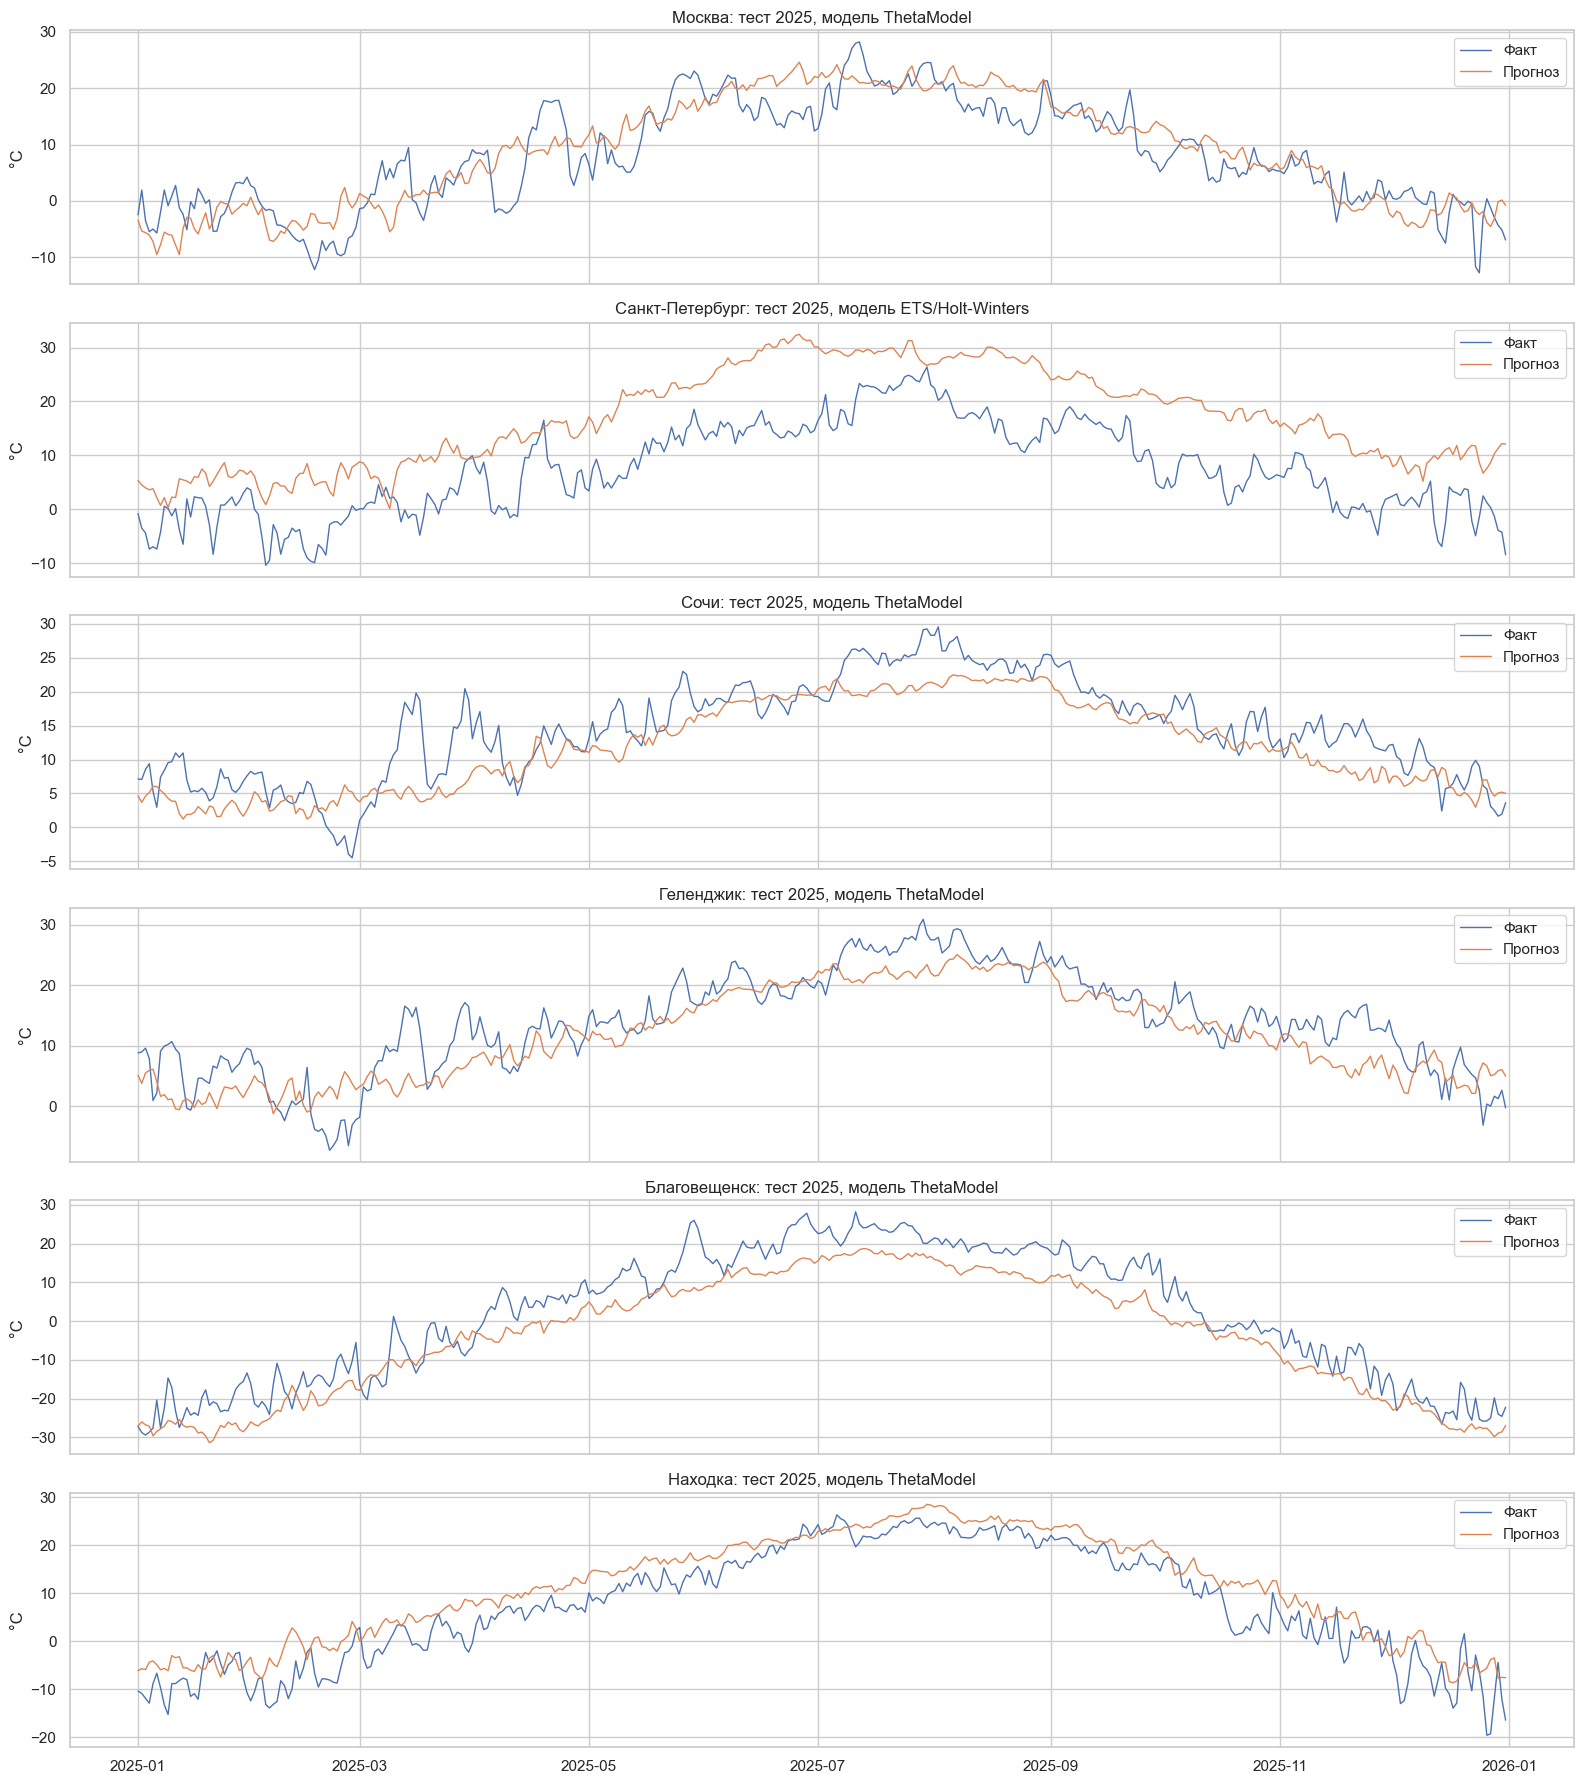

In [23]:
# Графики прогноз vs факт на тестовом периоде.
fig, axes = plt.subplots(len(CITY_ORDER), 1, figsize=(16, 18), sharex=True)
for ax, city in zip(axes, CITY_ORDER):
    pred_df = test_predictions[city]
    ax.plot(pred_df.index, pred_df['y_true'], label='Факт', linewidth=1.0)
    ax.plot(pred_df.index, pred_df['y_pred'], label='Прогноз', linewidth=1.0)
    ax.set_title(f'{city}: тест 2025, модель {selected_models[city]}')
    ax.set_ylabel('°C')
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '10_forecast_test_fact_vs_pred.png', dpi=160)
plt.show()

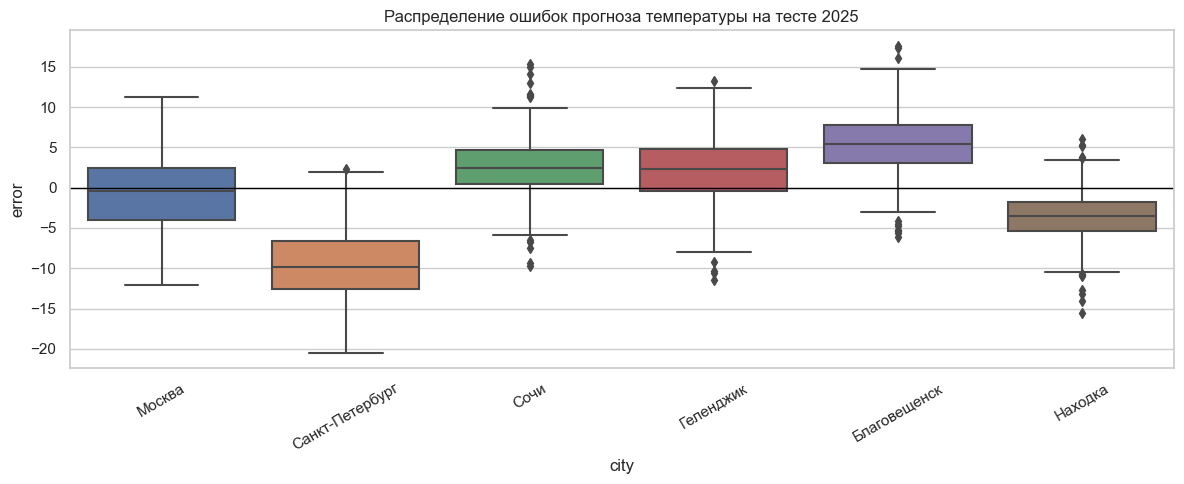

In [24]:
# Распределение ошибок по городам.
error_parts = []
for city, pred_df in test_predictions.items():
    tmp = pred_df.copy()
    tmp['city'] = city
    tmp['error'] = tmp['y_true'] - tmp['y_pred']
    tmp['abs_error'] = tmp['error'].abs()
    error_parts.append(tmp.reset_index().rename(columns={'index': 'time'}))
errors_all = pd.concat(error_parts, ignore_index=True)

plt.figure(figsize=(12, 5))
sns.boxplot(data=errors_all, x='city', y='error')
plt.axhline(0, color='black', linewidth=1)
plt.title('Распределение ошибок прогноза температуры на тесте 2025')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / '11_forecast_error_boxplot.png', dpi=160)
plt.show()

,city,horizon_day,MAE,RMSE,MAPE,WAPE,direction_accuracy
0,Москва,1,3.664293,4.406041,73.752982,42.347643,0.583333
1,Москва,2,3.646431,4.996277,101.040213,42.414588,0.583333
2,Москва,3,2.605342,3.619896,141.754741,30.312751,0.666667
3,Москва,4,2.495573,3.213478,64.216697,25.953093,0.750000
4,Москва,5,2.352309,3.071679,102.399677,25.090439,0.750000


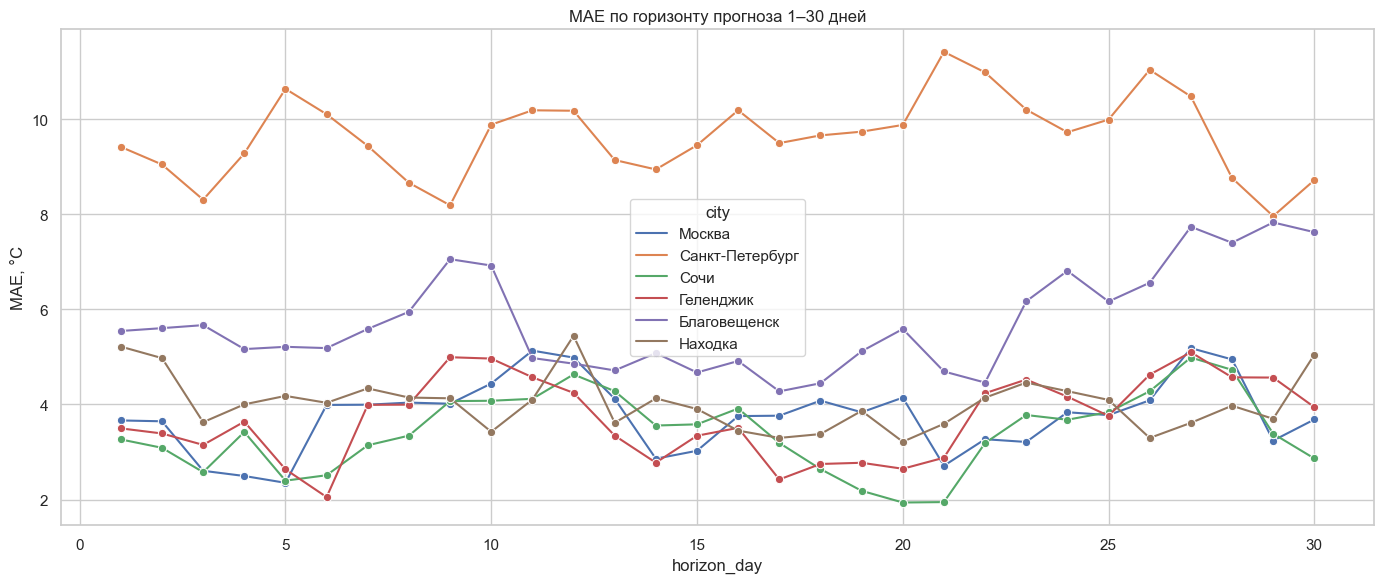

In [25]:
# Метрики по горизонту 1..30 внутри последовательных 30-дневных блоков тестового периода.
horizon_rows = []
for city, pred_df in test_predictions.items():
    tmp = pred_df.copy().reset_index().rename(columns={'index': 'time'})
    tmp['horizon_day'] = (np.arange(len(tmp)) % 30) + 1
    for h, g in tmp.groupby('horizon_day'):
        m = forecast_metrics(g.set_index('time')['y_true'], g.set_index('time')['y_pred'])
        horizon_rows.append({'city': city, 'horizon_day': h, **m})

horizon_metrics = pd.DataFrame(horizon_rows)
display(horizon_metrics.head())

plt.figure(figsize=(14, 6))
sns.lineplot(data=horizon_metrics, x='horizon_day', y='MAE', hue='city', marker='o')
plt.title('MAE по горизонту прогноза 1–30 дней')
plt.ylabel('MAE, °C')
plt.tight_layout()
plt.savefig(FIG_DIR / '12_mae_by_horizon.png', dpi=160)
plt.show()

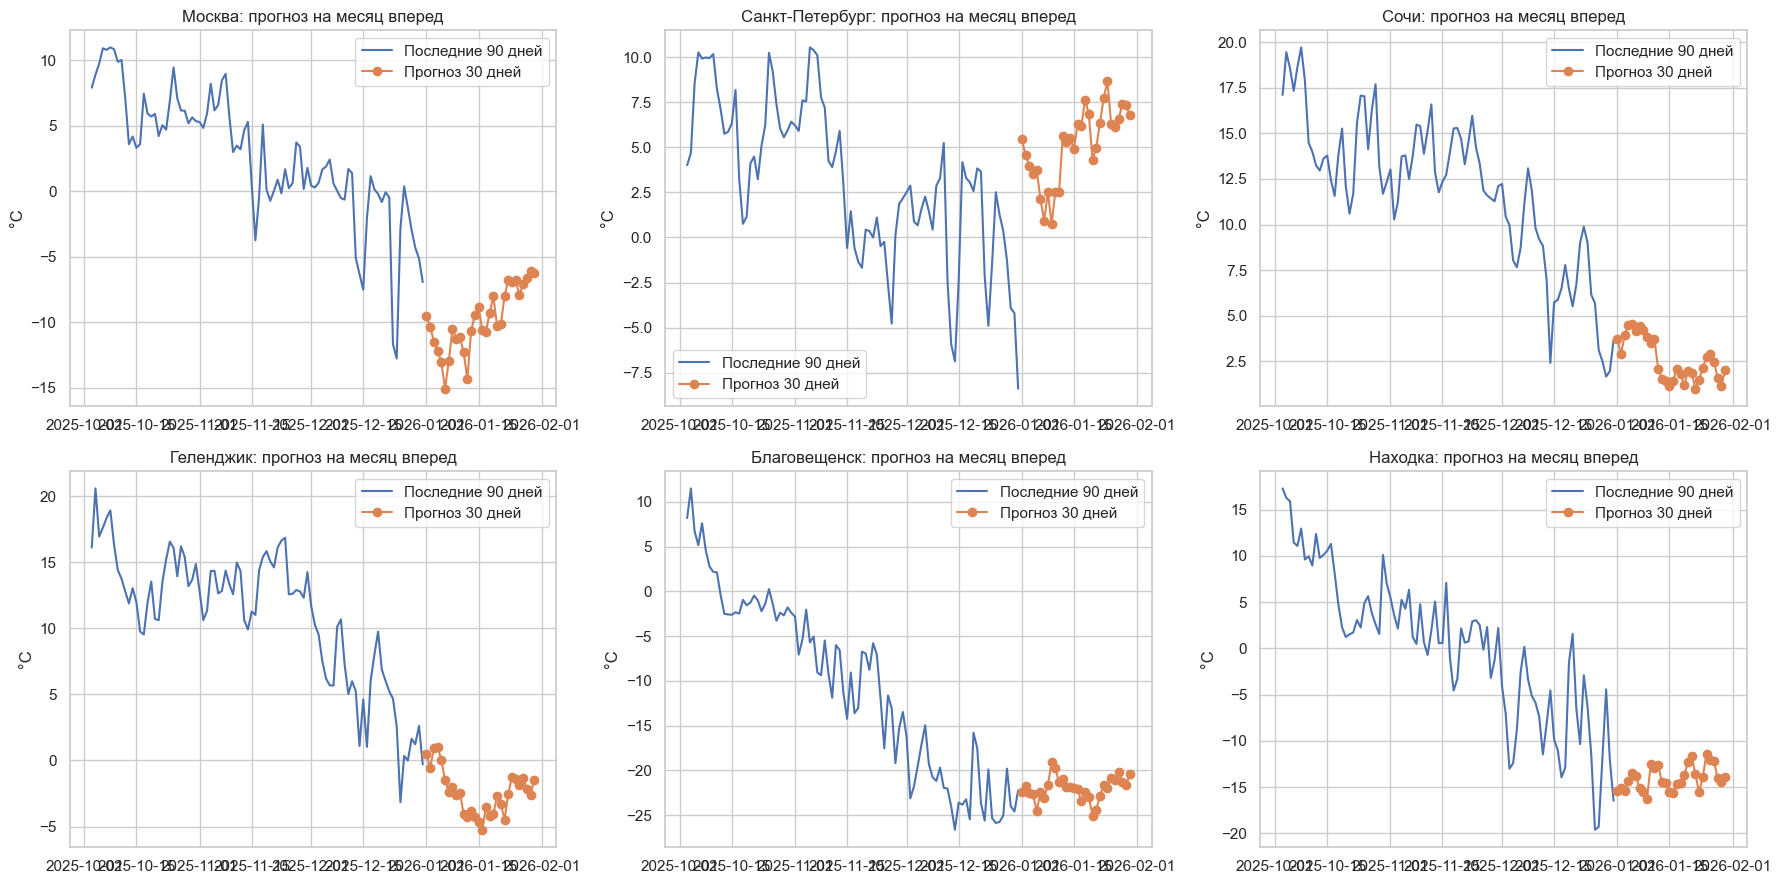

,Москва,Санкт-Петербург,Сочи,Геленджик,Благовещенск,Находка
2026-01-01,-9.501114,5.470977,3.701808,0.512147,-22.414796,-15.402974
2026-01-02,-10.358175,4.550490,2.899857,-0.599594,-21.755550,-15.137025
2026-01-03,-11.495214,3.986844,3.925621,0.945649,-22.505903,-15.468309
2026-01-04,-12.186715,3.496666,4.493237,1.028920,-22.674502,-14.351857
2026-01-05,-13.045681,3.715121,4.560118,0.021663,-24.555616,-13.448825
2026-01-06,-15.093708,2.119951,4.172556,-1.494435,-22.420840,-13.783541
2026-01-07,-13.003835,0.920888,4.430796,-2.356735,-23.074236,-15.149428
2026-01-08,-10.507833,2.523684,4.186808,-1.977603,-21.649743,-15.496835
2026-01-09,-11.303079,0.752282,3.811134,-2.622042,-19.121408,-16.242163
2026-01-10,-11.157961,2.518916,3.488156,-2.445898,-19.755678,-12.527824


In [26]:
# Прогноз на следующие 30 дней после конца доступного периода.
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()
for ax, city in zip(axes, CITY_ORDER):
    y = make_city_series(city)
    hist = y.iloc[-90:]
    future = future_forecasts[city]
    ax.plot(hist.index, hist.values, label='Последние 90 дней')
    ax.plot(future.index, future.values, label='Прогноз 30 дней', marker='o')
    ax.set_title(f'{city}: прогноз на месяц вперед')
    ax.set_ylabel('°C')
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '13_future_30_days_forecast.png', dpi=160)
plt.show()

future_forecast_table = pd.concat(
    [future_forecasts[city].rename(city) for city in CITY_ORDER],
    axis=1,
)
display(future_forecast_table.head(30))

**Вывод по прогнозированию.** Раздельные модели по городам лучше соответствуют постановке задачи, чем одна универсальная модель на все города: сезонность и амплитуда температуры сильно различаются. ETS обычно хорошо работает там, где годовая сезонность стабильна, а ThetaModel может быть устойчивее, когда ETS переоценивает тренд или сезонную компоненту. Остатки не обязаны быть нормально распределены: для погоды характерны автокорреляция и экстремальные события, поэтому диагностика остатков нужна не для «идеальности» модели, а для понимания ее ограничений.

## 2.7. Интеграция двух этапов в единый пайплайн

Ниже реализован прототип двухэтапной системы:

1. На вход поступает последнее 30-дневное окно метеопараметров.
2. DTW-классификатор определяет климатическую зону.
3. Если город известен, используется городская прогнозная модель. Если город не задан, выбирается наиболее похожий город из предсказанной климатической зоны по агрегированному температурному профилю окна.
4. Возвращается прогноз температуры на 30 дней.

In [27]:
def classify_recent_window(window_df: pd.DataFrame) -> dict:
    """Классифицирует климатическую зону по 30-дневному окну."""
    if len(window_df) != WINDOW:
        raise ValueError(f'Окно должно содержать ровно {WINDOW} дней')
    x = window_df[CLASSIFICATION_FEATURES].values.astype(np.float32)[None, :, :]
    x_scaled = seq_scaler.transform(x.reshape(-1, len(CLASSIFICATION_FEATURES))).reshape(x.shape).astype(np.float32)
    proba = clf_dtw.predict_proba(x_scaled)[0]
    pred_idx = int(np.argmax(proba))
    pred_zone = label_encoder.inverse_transform([pred_idx])[0]
    return {
        'predicted_zone': pred_zone,
        'predicted_zone_ru': CLIMATE_ZONE_RU[pred_zone],
        'probabilities': dict(zip(label_encoder.classes_, proba.round(4))),
    }


def choose_city_by_profile(window_df: pd.DataFrame, predicted_zone: str) -> str:
    """Если город неизвестен, выбирает ближайший город внутри зоны по простому температурному профилю."""
    candidates = [city for city, zone in CLIMATE_ZONE.items() if zone == predicted_zone]
    profile = np.array([
        window_df['temperature_2m'].mean(),
        window_df['temperature_2m'].std(),
        window_df['temperature_2m'].min(),
        window_df['temperature_2m'].max(),
        window_df['precipitation'].sum(),
    ])
    best_city, best_dist = None, np.inf
    for city in candidates:
        city_hist = daily[daily['city'] == city]
        city_profile = np.array([
            city_hist['temperature_2m'].mean(),
            city_hist['temperature_2m'].std(),
            city_hist['temperature_2m'].min(),
            city_hist['temperature_2m'].max(),
            city_hist['precipitation'].mean() * WINDOW,
        ])
        dist = np.linalg.norm(profile - city_profile)
        if dist < best_dist:
            best_dist = dist
            best_city = city
    return best_city


def run_two_stage_pipeline(recent_window: pd.DataFrame, city: str | None = None) -> dict:
    classification = classify_recent_window(recent_window)
    predicted_zone = classification['predicted_zone']
    selected_city = city
    if selected_city is None:
        selected_city = choose_city_by_profile(recent_window, predicted_zone)
    if CLIMATE_ZONE[selected_city] != predicted_zone:
        print(
            'Предупреждение: указанный город относится к другой зоне, чем предсказал классификатор. '
            'Для прогноза используется указанный город.'
        )
    return {
        'classification': classification,
        'selected_city_for_forecast': selected_city,
        'selected_forecast_model': selected_models[selected_city],
        'forecast_30_days': future_forecasts[selected_city],
    }

# Демонстрация: берем последние 30 дней Москвы как новое входное окно.
example_city = 'Москва'
example_window = daily[daily['city'] == example_city].sort_values('time').tail(WINDOW)
pipeline_result = run_two_stage_pipeline(example_window, city=example_city)

print('Предсказанная климатическая зона:', pipeline_result['classification']['predicted_zone_ru'])
print('Вероятности:', pipeline_result['classification']['probabilities'])
print('Город для прогноза:', pipeline_result['selected_city_for_forecast'])
print('Модель прогноза:', pipeline_result['selected_forecast_model'])
display(pipeline_result['forecast_30_days'].head())

Предсказанная климатическая зона: умеренно-континентальная / северо-западная
Вероятности: {'black_sea_subtropical': 0.0, 'continental_northwest': 1.0, 'far_east_monsoon': 0.0}
Город для прогноза: Москва
Модель прогноза: ThetaModel


2026-01-01    -9.501114
2026-01-02   -10.358175
2026-01-03   -11.495214
2026-01-04   -12.186715
2026-01-05   -13.045681
Freq: D, Name: forecast, dtype: float64

**Вывод по интеграции.** Двухэтапная схема практически оправдана: классификатор определяет тип климатического режима по текущему окну, а прогноз строится не универсальной моделью, а моделью, обученной на конкретном городе. Такая схема лучше соответствует физике задачи, потому что разные климатические зоны имеют разные сезонные профили и разную амплитуду температуры.

## 2.8. Итоговая сводная таблица и интерпретация

Ниже объединяются результаты классификации и прогнозирования.

In [28]:
summary_table = forecast_results.merge(
    residual_table,
    on='city',
    how='left',
)
summary_table['classification_model'] = 'kNN + DTW'
summary_table['classification_accuracy_test'] = float(classification_metrics['accuracy'].iloc[0])
summary_table['classification_f1_macro_test'] = float(classification_metrics['f1_macro'].iloc[0])
summary_table['classification_roc_auc_ovr_macro_test'] = float(classification_metrics['roc_auc_ovr_macro'].iloc[0])

summary_cols = [
    'city', 'climate_zone', 'classification_model', 'classification_accuracy_test',
    'classification_f1_macro_test', 'classification_roc_auc_ovr_macro_test',
    'selected_model', 'MAE', 'RMSE', 'MAPE', 'WAPE', 'direction_accuracy',
    'shapiro_pvalue', 'ljung_box_pvalue_lag30', 'white_pvalue'
]
summary_table = summary_table[summary_cols]
display(summary_table)

summary_table.to_csv(PROJECT_DIR / 'outputs' / 'summary_results.csv', index=False)
classification_metrics.to_csv(PROJECT_DIR / 'outputs' / 'classification_metrics.csv', index=False)
forecast_results.to_csv(PROJECT_DIR / 'outputs' / 'forecast_results.csv', index=False)
residual_table.to_csv(PROJECT_DIR / 'outputs' / 'residual_diagnostics.csv', index=False)
print('Таблицы сохранены в outputs/')

,city,climate_zone,classification_model,classification_accuracy_test,classification_f1_macro_test,classification_roc_auc_ovr_macro_test,selected_model,MAE,RMSE,MAPE,WAPE,direction_accuracy,shapiro_pvalue,ljung_box_pvalue_lag30,white_pvalue
0,Москва,continental_northwest,kNN + DTW,0.805556,0.803865,0.947917,ThetaModel,3.752397,4.675586,221.170177,38.631949,0.510989,0.205282,1.776780e-154,8.647355e-05
1,Санкт-Петербург,continental_northwest,kNN + DTW,0.805556,0.803865,0.947917,ETS/Holt-Winters,9.634250,10.474959,1152.574014,108.843752,0.502747,0.118043,3.904655e-126,6.775665e-11
2,Сочи,black_sea_subtropical,kNN + DTW,0.805556,0.803865,0.947917,ThetaModel,3.414019,4.335625,38.489729,23.484908,0.483516,0.000109,2.532254e-179,6.694717e-09
3,Геленджик,black_sea_subtropical,kNN + DTW,0.805556,0.803865,0.947917,ThetaModel,3.696436,4.567076,225.813848,26.103997,0.519231,0.084365,3.544447e-184,4.769442e-10
4,Благовещенск,far_east_monsoon,kNN + DTW,0.805556,0.803865,0.947917,ThetaModel,5.729837,6.612985,88.425593,39.010079,0.516484,0.088153,8.577887e-56,4.555415e-07
5,Находка,far_east_monsoon,kNN + DTW,0.805556,0.803865,0.947917,ThetaModel,4.027925,4.812369,110.474330,34.916917,0.500000,0.002279,2.555558e-37,1.060463e-12


Таблицы сохранены в outputs/


## Общие выводы

1. Данные имеют выраженную годовую сезонность температуры и импульсную структуру осадков, поэтому перед моделированием необходимо привести ряды к единой частоте и учитывать сезонные паттерны.
2. Автоматическое удаление выбросов для метеоданных нежелательно: экстремальные значения могут быть реальными опасными явлениями.
3. Для классификации климатической зоны лучше использовать модель, учитывающую форму временного ряда. В этой работе использован `kNN + DTW`, потому что он сравнивает многомерные 30-дневные погодные окна с учетом временных сдвигов.
4. Для прогноза температуры на месяц вперед целесообразно обучать отдельные модели по городам. Одна универсальная модель смешивала бы разные климатические режимы.
5. ETS/Holt-Winters и ThetaModel являются специализированными моделями временных рядов: они напрямую учитывают уровень, тренд и сезонность, поэтому лучше соответствуют требованию задания, чем обычные табличные бустинги.
6. Двухэтапный подход применим для метеоданных: сначала определяется климатический режим, затем используется специализированная прогнозная модель для города/зоны.